# Normalizing Flow - Conditional Population of Stars

This notebook reads the tutorial conditional stellar NPZ, adds uniform Gaussian photometric noise during preprocessing, standardizes the observed CMD together with the conditioning signal `(log_tau, feh)`, and trains a conditional autoregressive spline flow by maximum likelihood.

The train/validation split is done at the **population_id** level so each held-out validation population is entirely unseen during training.


In [1]:
import time
from pathlib import Path
from typing import Tuple

import jax

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from flax import linen as nn
from flax.training import train_state
from matplotlib.ticker import MultipleLocator
from tqdm.auto import tqdm

plt.style.use("default")
plt.rcParams.update(
    {
        "axes.grid": False,
        "axes.linewidth": 1.1,
        "font.size": 11,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    }
)


def find_repo_root() -> Path:
    root = Path.cwd().resolve()
    while not (root / "environment-isochrones.yml").exists() and root != root.parent:
        root = root.parent
    return root


ROOT = find_repo_root()
DATA_PATH = ROOT / "tutorial_data" / "tutorial_conditional_population.npz"

SOURCE_REQUIRED_COLUMNS = ("G", "BP", "RP", "population_index", "log_tau", "feh")
POPULATION_TABLE_REQUIRED_COLUMNS = ("population_index", "log_tau", "feh")
CMD_OBS_COLUMNS = ("BP_minus_RP_obs", "M_G_obs")
CONDITION_COLUMNS = ("log_tau", "feh")
CMD_COLOR_COLUMN = 0
CMD_GMAG_COLUMN = 1
LOG_TAU_COLUMN = 0
FEH_COLUMN = 1

OBSERVATION_NOISE_MEAN = 0.0
OBSERVATION_NOISE_STD = 0.03
OBSERVATION_NOISE_SEED = 7

print(f"JAX backend: {jax.default_backend()}")
print(f"Primary device: {jax.devices()[0]}")
print(f"Tutorial data path: {DATA_PATH.relative_to(ROOT)}")
print("Expected source columns:", SOURCE_REQUIRED_COLUMNS)
print("Expected population table columns:", POPULATION_TABLE_REQUIRED_COLUMNS)
print("Observed CMD columns rebuilt in this notebook:", CMD_OBS_COLUMNS)
print("Condition columns:", CONDITION_COLUMNS)
print(f"Per-filter noise std: {OBSERVATION_NOISE_STD:.3f} mag")

catalog = np.load(DATA_PATH)

raw_data = catalog["data"].astype(np.float32)
raw_columns = tuple(str(name) for name in catalog["columns"].tolist())
population_table = catalog["population_table"].astype(np.float32)
population_table_columns = tuple(str(name) for name in catalog["population_table_columns"].tolist())
catalog_seed = int(catalog["catalog_seed"])
sample_seed_start = int(catalog["sample_seed_start"])

if raw_data.ndim != 2:
    raise ValueError(f"Expected tutorial data to be 2D, got shape {raw_data.shape}.")
if raw_data.shape[1] != len(raw_columns):
    raise ValueError(
        f"Expected {len(raw_columns)} source columns, got data shape {raw_data.shape}."
    )
if population_table.ndim != 2:
    raise ValueError(f"Expected population table to be 2D, got shape {population_table.shape}.")
if population_table.shape[1] != len(population_table_columns):
    raise ValueError(
        "Population table width does not match declared population-table columns."
    )

missing_source_columns = [name for name in SOURCE_REQUIRED_COLUMNS if name not in raw_columns]
if missing_source_columns:
    raise ValueError(f"Missing required source columns: {missing_source_columns}")

missing_population_columns = [
    name for name in POPULATION_TABLE_REQUIRED_COLUMNS if name not in population_table_columns
]
if missing_population_columns:
    raise ValueError(f"Missing required population table columns: {missing_population_columns}")

column_to_index = {name: idx for idx, name in enumerate(raw_columns)}
population_table_column_to_index = {
    name: idx for idx, name in enumerate(population_table_columns)
}

g_clean = raw_data[:, column_to_index["G"]]
bp_clean = raw_data[:, column_to_index["BP"]]
rp_clean = raw_data[:, column_to_index["RP"]]
population_id = raw_data[:, column_to_index["population_index"]].astype(np.int32)
log_tau = raw_data[:, column_to_index["log_tau"]]
feh = raw_data[:, column_to_index["feh"]]

noise_rng = np.random.default_rng(OBSERVATION_NOISE_SEED)
noise_g = noise_rng.normal(
    loc=OBSERVATION_NOISE_MEAN,
    scale=OBSERVATION_NOISE_STD,
    size=len(raw_data),
).astype(np.float32)
noise_bp = noise_rng.normal(
    loc=OBSERVATION_NOISE_MEAN,
    scale=OBSERVATION_NOISE_STD,
    size=len(raw_data),
).astype(np.float32)
noise_rp = noise_rng.normal(
    loc=OBSERVATION_NOISE_MEAN,
    scale=OBSERVATION_NOISE_STD,
    size=len(raw_data),
).astype(np.float32)

g_obs = (g_clean + noise_g).astype(np.float32)
bp_obs = (bp_clean + noise_bp).astype(np.float32)
rp_obs = (rp_clean + noise_rp).astype(np.float32)

bp_rp_obs = (bp_obs - rp_obs).astype(np.float32)
M_G_obs = g_obs.copy()

cmd_observed = np.column_stack([bp_rp_obs, M_G_obs]).astype(np.float32)
conditioning = np.column_stack([log_tau, feh]).astype(np.float32)

unique_population_ids = population_table[
    :, population_table_column_to_index["population_index"]
].astype(np.int32)
population_log_tau = population_table[:, population_table_column_to_index["log_tau"]].astype(np.float32)
population_feh = population_table[:, population_table_column_to_index["feh"]].astype(np.float32)
population_conditioning = np.column_stack([population_log_tau, population_feh]).astype(np.float32)

if not np.array_equal(np.unique(population_id), unique_population_ids):
    raise ValueError("Population ids in the data and population table do not match.")

population_id_width = max(3, len(str(len(unique_population_ids) - 1)))

val_fraction = 0.10
split_seed = 42

split_rng = np.random.default_rng(split_seed)
shuffled_population_ids = unique_population_ids.copy()
split_rng.shuffle(shuffled_population_ids)

n_val_populations = max(1, int(val_fraction * len(unique_population_ids)))
val_population_ids = np.sort(shuffled_population_ids[:n_val_populations])
train_population_ids = np.sort(shuffled_population_ids[n_val_populations:])

train_population_mask = np.isin(unique_population_ids, train_population_ids)
val_population_mask = np.isin(unique_population_ids, val_population_ids)
train_mask = np.isin(population_id, train_population_ids)
val_mask = np.isin(population_id, val_population_ids)

x_train = cmd_observed[train_mask]
x_val = cmd_observed[val_mask]
condition_train = conditioning[train_mask]
condition_val = conditioning[val_mask]
train_population_condition = population_conditioning[train_population_mask]

x_mean = x_train.mean(axis=0)
x_std = x_train.std(axis=0)
cond_mean = train_population_condition.mean(axis=0)
cond_std = train_population_condition.std(axis=0)

if np.any(x_std <= 0.0):
    raise ValueError(f"Non-positive CMD standard deviation encountered: {x_std}")
if np.any(cond_std <= 0.0):
    raise ValueError(f"Non-positive condition standard deviation encountered: {cond_std}")

x_train_standardized = ((x_train - x_mean) / x_std).astype(np.float32)
x_val_standardized = ((x_val - x_mean) / x_std).astype(np.float32)
condition_train_standardized = ((condition_train - cond_mean) / cond_std).astype(np.float32)
condition_val_standardized = ((condition_val - cond_mean) / cond_std).astype(np.float32)

train_array = x_train_standardized.astype(np.float32)
val_array = x_val_standardized.astype(np.float32)
train_condition_array = condition_train_standardized.astype(np.float32)
val_condition_array = condition_val_standardized.astype(np.float32)

print(f"Catalog size:            {len(raw_data):,}")
print(f"Number of populations:   {len(unique_population_ids):,}")
print("Stored columns:         ", raw_columns)
print("Population-table cols:  ", population_table_columns)
print(f"Catalog seed:            {catalog_seed}")
print(f"Sample seed start:       {sample_seed_start}")
print()
print("Tutorial generator assumptions used here: distance_pc = 10.0, AV = 0.0")
print("That means the stored G magnitude is already M_G.")
print()
print(f"Observed color range:    {bp_rp_obs.min():.3f} .. {bp_rp_obs.max():.3f}")
print(f"Observed M_G range:      {M_G_obs.min():.3f} .. {M_G_obs.max():.3f}")
print(f"log_tau range:           {log_tau.min():.3f} .. {log_tau.max():.3f}")
print(f"[Fe/H] range:            {feh.min():.3f} .. {feh.max():.3f}")
print()
print(f"Train populations:       {len(train_population_ids):,}")
print(f"Validation populations:  {len(val_population_ids):,}")
print(f"Train stars:             {len(x_train):,}")
print(f"Validation stars:        {len(x_val):,}")
print()
print("Observed-data mean:", x_mean)
print("Observed-data std: ", x_std)
print("Condition mean:    ", cond_mean)
print("Condition std:     ", cond_std)


JAX backend: cpu
Primary device: TFRT_CPU_0
Tutorial data path: tutorial_data/tutorial_conditional_population.npz
Expected source columns: ('G', 'BP', 'RP', 'population_index', 'log_tau', 'feh')
Expected population table columns: ('population_index', 'log_tau', 'feh')
Observed CMD columns rebuilt in this notebook: ('BP_minus_RP_obs', 'M_G_obs')
Condition columns: ('log_tau', 'feh')
Per-filter noise std: 0.030 mag
Catalog size:            100,000
Number of populations:   1,000
Stored columns:          ('G', 'BP', 'RP', 'population_index', 'log_tau', 'feh')
Population-table cols:   ('population_index', 'log_tau', 'feh')
Catalog seed:            11
Sample seed start:       10000

Tutorial generator assumptions used here: distance_pc = 10.0, AV = 0.0
That means the stored G magnitude is already M_G.

Observed color range:    -0.604 .. 4.345
Observed M_G range:      -3.089 .. 7.434
log_tau range:           9.002 .. 9.799
[Fe/H] range:            -0.500 .. 0.249

Train populations:       900

/Users/tr/opt/anaconda3/envs/aemu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


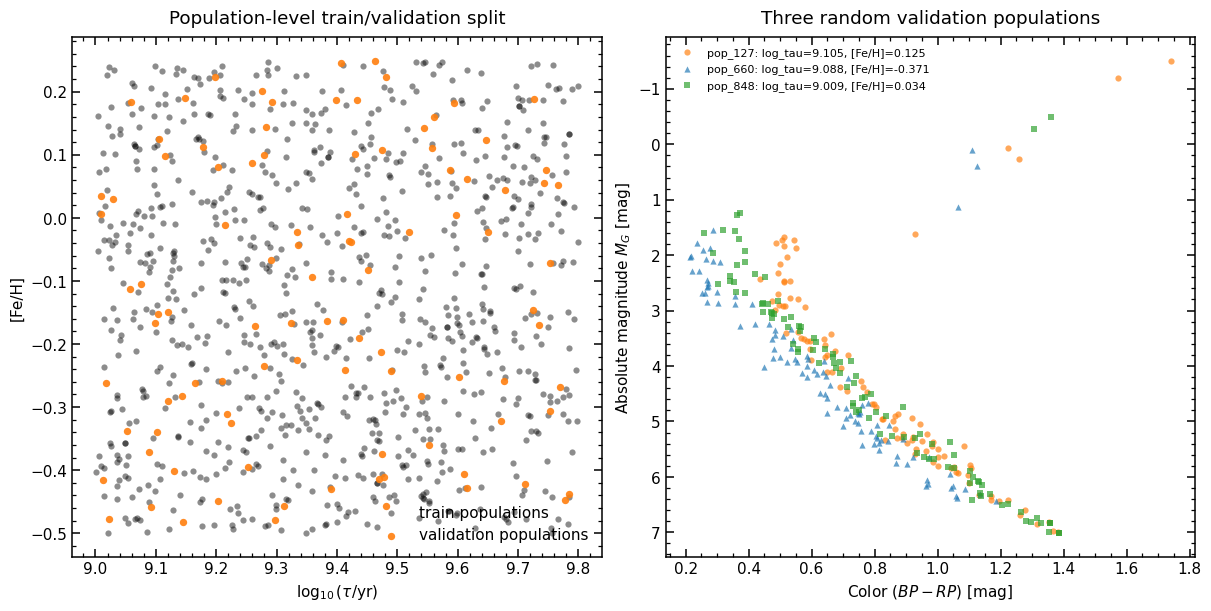

In [2]:
VALIDATION_PREVIEW_SEED = split_seed + 2
VALIDATION_PREVIEW_COUNT = min(3, len(val_population_ids))
VALIDATION_PREVIEW_COLORS = ("tab:orange", "tab:blue", "tab:green")
VALIDATION_PREVIEW_MARKERS = ("o", "^", "s")

preview_rng = np.random.default_rng(VALIDATION_PREVIEW_SEED)
preview_population_ids = np.sort(
    preview_rng.choice(
        val_population_ids,
        size=VALIDATION_PREVIEW_COUNT,
        replace=False,
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
ax_left, ax_right = axes

ax_left.scatter(
    population_conditioning[train_population_mask, LOG_TAU_COLUMN],
    population_conditioning[train_population_mask, FEH_COLUMN],
    s=20,
    alpha=0.45,
    color="black",
    linewidths=0,
    label="train populations",
    rasterized=True,
)
ax_left.scatter(
    population_conditioning[val_population_mask, LOG_TAU_COLUMN],
    population_conditioning[val_population_mask, FEH_COLUMN],
    s=28,
    alpha=0.90,
    color="tab:orange",
    linewidths=0,
    label="validation populations",
    rasterized=True,
)

ax_left.set_xlabel(r"$\log_{10}(\tau / \mathrm{yr})$")
ax_left.set_ylabel(r"[Fe/H]")
ax_left.set_title("Population-level train/validation split", pad=10)
ax_left.grid(False)
ax_left.legend(frameon=False)

ax_left.xaxis.set_major_locator(MultipleLocator(0.1))
ax_left.xaxis.set_minor_locator(MultipleLocator(0.02))
ax_left.yaxis.set_major_locator(MultipleLocator(0.1))
ax_left.yaxis.set_minor_locator(MultipleLocator(0.02))

for preview_index, preview_population_id in enumerate(preview_population_ids):
    preview_population_label = f"pop_{int(preview_population_id):0{population_id_width}d}"
    preview_population_mask = population_id == int(preview_population_id)
    preview_cmd = cmd_observed[preview_population_mask]
    preview_condition = conditioning[preview_population_mask][0]
    preview_color = VALIDATION_PREVIEW_COLORS[preview_index % len(VALIDATION_PREVIEW_COLORS)]
    preview_marker = VALIDATION_PREVIEW_MARKERS[preview_index % len(VALIDATION_PREVIEW_MARKERS)]

    ax_right.scatter(
        preview_cmd[:, CMD_COLOR_COLUMN],
        preview_cmd[:, CMD_GMAG_COLUMN],
        s=20,
        alpha=0.68,
        color=preview_color,
        marker=preview_marker,
        linewidths=0,
        rasterized=True,
        label=(
            f"{preview_population_label}: "
            f"log_tau={preview_condition[LOG_TAU_COLUMN]:.3f}, "
            f"[Fe/H]={preview_condition[FEH_COLUMN]:.3f}"
        ),
    )

ax_right.set_xlabel(r"Color $(BP - RP)$ [mag]")
ax_right.set_ylabel(r"Absolute magnitude $M_G$ [mag]")
ax_right.set_title("Three random validation populations", pad=10)
ax_right.invert_yaxis()
ax_right.grid(False)
ax_right.legend(loc="upper left", frameon=False, fontsize=8)

ax_right.xaxis.set_major_locator(MultipleLocator(0.2))
ax_right.xaxis.set_minor_locator(MultipleLocator(0.05))
ax_right.yaxis.set_major_locator(MultipleLocator(1.0))
ax_right.yaxis.set_minor_locator(MultipleLocator(0.2))

for ax in axes:
    ax.tick_params(which="major", length=6, width=1.1)
    ax.tick_params(which="minor", length=3, width=0.9)
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)

plt.show()


We now model the **standardized observed CMD** `x`, while also providing the standardized conditioning vector

$$
c = (\log_{10}(\tau / \mathrm{yr}), [\mathrm{Fe}/\mathrm{H}]).
$$

The flow is a conditional autoregressive spline transform with base variable

$$
u \sim \mathcal{N}(0, I_2),
$$

and triangular map

$$
x_1 = f_{\psi,1}(u_1; c), \qquad x_2 = f_{\psi,2}(u_2; x_1, c).
$$

Because each component is monotone, the conditional likelihood is tractable:

$$
\log p_\psi(x \mid c) = \log p(u) + \sum_{i=1}^2 \log \left|\frac{\partial u_i}{\partial x_i}\right|.
$$


In [3]:
LOG_2PI = np.log(2.0 * np.pi)

def _softplus_inverse(y: float) -> float:
    return float(np.log(np.expm1(y)))

def _unconstrained_spline_params(
    raw_widths: jax.Array,
    raw_heights: jax.Array,
    raw_derivatives: jax.Array,
    bound: float,
    min_bin_width: float = 1e-3,
    min_bin_height: float = 1e-3,
    min_derivative: float = 1e-3,
) -> tuple[jax.Array, jax.Array, jax.Array, jax.Array, jax.Array]:
    num_bins = raw_widths.shape[-1]

    widths = nn.softmax(raw_widths, axis=-1)
    widths = min_bin_width + (2.0 * bound - min_bin_width * num_bins) * widths
    cumwidths = jnp.cumsum(widths, axis=-1)
    cumwidths = jnp.pad(
        cumwidths,
        [(0, 0)] * (cumwidths.ndim - 1) + [(1, 0)],
        constant_values=0.0,
    )
    cumwidths = cumwidths + (-bound)
    cumwidths = cumwidths.at[..., 0].set(-bound)
    cumwidths = cumwidths.at[..., -1].set(bound)

    heights = nn.softmax(raw_heights, axis=-1)
    heights = min_bin_height + (2.0 * bound - min_bin_height * num_bins) * heights
    cumheights = jnp.cumsum(heights, axis=-1)
    cumheights = jnp.pad(
        cumheights,
        [(0, 0)] * (cumheights.ndim - 1) + [(1, 0)],
        constant_values=0.0,
    )
    cumheights = cumheights + (-bound)
    cumheights = cumheights.at[..., 0].set(-bound)
    cumheights = cumheights.at[..., -1].set(bound)

    interior = min_derivative + nn.softplus(raw_derivatives)
    ones = jnp.ones((*interior.shape[:-1], 1), dtype=interior.dtype)
    derivatives = jnp.concatenate([ones, interior, ones], axis=-1)
    return widths, cumwidths, heights, cumheights, derivatives


def _searchsorted(bin_locations: jax.Array, inputs: jax.Array) -> jax.Array:
    idx = jnp.sum(inputs[..., None] >= bin_locations[..., 1:], axis=-1)
    num_bins = bin_locations.shape[-1] - 1
    return jnp.clip(idx, 0, num_bins - 1)


def _gather(arr: jax.Array, idx: jax.Array) -> jax.Array:
    return jnp.take_along_axis(arr, idx[..., None], axis=-1)[..., 0]


def rqs_forward(
    inputs: jax.Array,
    raw_widths: jax.Array,
    raw_heights: jax.Array,
    raw_derivatives: jax.Array,
    *,
    bound: float = 6.0,
    min_bin_width: float = 1e-3,
    min_bin_height: float = 1e-3,
    min_derivative: float = 1e-3,
) -> tuple[jax.Array, jax.Array]:
    widths, cumwidths, heights, cumheights, derivatives = _unconstrained_spline_params(
        raw_widths,
        raw_heights,
        raw_derivatives,
        bound,
        min_bin_width,
        min_bin_height,
        min_derivative,
    )

    inside = (inputs >= -bound) & (inputs <= bound)
    safe_inputs = jnp.where(inside, inputs, jnp.zeros_like(inputs))
    bin_idx = _searchsorted(cumwidths, safe_inputs)

    input_cumwidths = _gather(cumwidths[..., :-1], bin_idx)
    input_bin_widths = _gather(widths, bin_idx)
    input_cumheights = _gather(cumheights[..., :-1], bin_idx)
    input_bin_heights = _gather(heights, bin_idx)
    input_delta = input_bin_heights / input_bin_widths
    input_derivatives = _gather(derivatives[..., :-1], bin_idx)
    input_derivatives_plus_one = _gather(derivatives[..., 1:], bin_idx)

    theta = (safe_inputs - input_cumwidths) / input_bin_widths
    theta = jnp.clip(theta, 0.0, 1.0)
    theta_omt = theta * (1.0 - theta)

    numerator = input_bin_heights * (
        input_delta * theta**2 + input_derivatives * theta_omt
    )
    denominator = input_delta + (
        (input_derivatives + input_derivatives_plus_one - 2.0 * input_delta)
        * theta_omt
    )
    denominator = jnp.maximum(denominator, 1e-6)
    outputs = input_cumheights + numerator / denominator

    derivative_numerator = input_delta**2 * (
        input_derivatives_plus_one * theta**2
        + 2.0 * input_delta * theta_omt
        + input_derivatives * (1.0 - theta) ** 2
    )
    derivative_numerator = jnp.maximum(derivative_numerator, 1e-6)
    logabsdet = jnp.log(derivative_numerator) - 2.0 * jnp.log(denominator)

    outputs = jnp.where(inside, outputs, inputs)
    logabsdet = jnp.where(inside, logabsdet, 0.0)
    return outputs, logabsdet


def rqs_inverse(
    inputs: jax.Array,
    raw_widths: jax.Array,
    raw_heights: jax.Array,
    raw_derivatives: jax.Array,
    *,
    bound: float = 6.0,
    min_bin_width: float = 1e-3,
    min_bin_height: float = 1e-3,
    min_derivative: float = 1e-3,
) -> tuple[jax.Array, jax.Array]:
    widths, cumwidths, heights, cumheights, derivatives = _unconstrained_spline_params(
        raw_widths,
        raw_heights,
        raw_derivatives,
        bound,
        min_bin_width,
        min_bin_height,
        min_derivative,
    )

    inside = (inputs >= -bound) & (inputs <= bound)
    safe_inputs = jnp.where(inside, inputs, jnp.zeros_like(inputs))
    bin_idx = _searchsorted(cumheights, safe_inputs)

    input_cumwidths = _gather(cumwidths[..., :-1], bin_idx)
    input_bin_widths = _gather(widths, bin_idx)
    input_cumheights = _gather(cumheights[..., :-1], bin_idx)
    input_bin_heights = _gather(heights, bin_idx)
    input_delta = input_bin_heights / input_bin_widths
    input_derivatives = _gather(derivatives[..., :-1], bin_idx)
    input_derivatives_plus_one = _gather(derivatives[..., 1:], bin_idx)

    shifted = safe_inputs - input_cumheights
    a = shifted * (input_derivatives + input_derivatives_plus_one - 2.0 * input_delta)
    a = a + input_bin_heights * (input_delta - input_derivatives)
    b = input_bin_heights * input_derivatives
    b = b - shifted * (input_derivatives + input_derivatives_plus_one - 2.0 * input_delta)
    c = -input_delta * shifted

    discriminant = jnp.maximum(b**2 - 4.0 * a * c, 0.0)
    quad_denominator = -b - jnp.sqrt(discriminant)
    quad_denominator = jnp.where(
        jnp.abs(quad_denominator) < 1e-6,
        jnp.where(quad_denominator < 0.0, -1e-6, 1e-6),
        quad_denominator,
    )
    b_safe = jnp.where(
        jnp.abs(b) < 1e-6,
        jnp.where(b < 0.0, -1e-6, 1e-6),
        b,
    )
    root_quadratic = (2.0 * c) / quad_denominator
    root_linear = -c / b_safe
    theta = jnp.where(jnp.abs(a) < 1e-6, root_linear, root_quadratic)
    theta = jnp.clip(theta, 0.0, 1.0)

    outputs = theta * input_bin_widths + input_cumwidths

    theta_omt = theta * (1.0 - theta)
    denominator = input_delta + (
        (input_derivatives + input_derivatives_plus_one - 2.0 * input_delta)
        * theta_omt
    )
    derivative_numerator = input_delta**2 * (
        input_derivatives_plus_one * theta**2
        + 2.0 * input_delta * theta_omt
        + input_derivatives * (1.0 - theta) ** 2
    )
    denominator = jnp.maximum(denominator, 1e-6)
    derivative_numerator = jnp.maximum(derivative_numerator, 1e-6)
    logabsdet = -(jnp.log(derivative_numerator) - 2.0 * jnp.log(denominator))

    outputs = jnp.where(inside, outputs, inputs)
    logabsdet = jnp.where(inside, logabsdet, 0.0)
    return outputs, logabsdet


class SplineConditioner(nn.Module):
    num_bins: int = 16
    hidden_features: Tuple[int, ...] = (128, 128)
    min_derivative: float = 1e-3

    @nn.compact
    def __call__(self, features: jnp.ndarray) -> tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
        x = features
        for width in self.hidden_features:
            x = nn.swish(nn.Dense(width)(x))

        derivative_bias = _softplus_inverse(1.0 - self.min_derivative)

        raw_widths = nn.Dense(
            self.num_bins,
            kernel_init=nn.initializers.zeros_init(),
            bias_init=nn.initializers.zeros_init(),
        )(x)
        raw_heights = nn.Dense(
            self.num_bins,
            kernel_init=nn.initializers.zeros_init(),
            bias_init=nn.initializers.zeros_init(),
        )(x)
        raw_derivatives = nn.Dense(
            self.num_bins - 1,
            kernel_init=nn.initializers.zeros_init(),
            bias_init=nn.initializers.constant(derivative_bias),
        )(x)
        return raw_widths, raw_heights, raw_derivatives


class ConditionalAutoregressiveSplineFlow(nn.Module):
    num_bins: int = 16
    hidden_features: Tuple[int, ...] = (128, 128, 128)
    bound: float = 6.0
    min_derivative: float = 1e-3

    def setup(self):
        self.dim0_net = SplineConditioner(
            num_bins=self.num_bins,
            hidden_features=self.hidden_features,
            min_derivative=self.min_derivative,
        )
        self.dim1_net = SplineConditioner(
            num_bins=self.num_bins,
            hidden_features=self.hidden_features,
            min_derivative=self.min_derivative,
        )

    def __call__(self, x: jnp.ndarray, c: jnp.ndarray) -> tuple[jnp.ndarray, jnp.ndarray]:
        return self.inverse(x, c)

    def inverse(self, x: jnp.ndarray, c: jnp.ndarray) -> tuple[jnp.ndarray, jnp.ndarray]:
        x0 = x[:, 0]
        x1 = x[:, 1]

        raw0 = self.dim0_net(c)
        z0, logabsdet0 = rqs_inverse(x0, *raw0, bound=self.bound)

        raw1 = self.dim1_net(jnp.concatenate([c, x[:, :1]], axis=-1))
        z1, logabsdet1 = rqs_inverse(x1, *raw1, bound=self.bound)

        z = jnp.stack([z0, z1], axis=-1)
        return z, logabsdet0 + logabsdet1

    def forward(self, z: jnp.ndarray, c: jnp.ndarray) -> tuple[jnp.ndarray, jnp.ndarray]:
        z0 = z[:, 0]
        z1 = z[:, 1]

        raw0 = self.dim0_net(c)
        x0, logabsdet0 = rqs_forward(z0, *raw0, bound=self.bound)

        raw1 = self.dim1_net(jnp.concatenate([c, x0[:, None]], axis=-1))
        x1, logabsdet1 = rqs_forward(z1, *raw1, bound=self.bound)

        x = jnp.stack([x0, x1], axis=-1)
        return x, logabsdet0 + logabsdet1


def count_parameters(params) -> int:
    return sum(leaf.size for leaf in jax.tree_util.tree_leaves(params))


def make_learning_rate_schedule(
    learning_rate: float,
    train_steps: int,
    warmup_fraction: float,
):
    warmup_steps = max(1, int(train_steps * warmup_fraction))
    cosine_steps = max(train_steps - warmup_steps, 1)
    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=learning_rate,
        warmup_steps=warmup_steps,
        decay_steps=cosine_steps,
        end_value=0.0,
    )
    return schedule, warmup_steps, cosine_steps


### Run training

Training uses pure conditional maximum likelihood on the standardized CMD. Validation is deterministic because it evaluates the same held-out stars and held-out population conditions each time.


Model:                  ConditionalAutoregressiveSplineFlow
Trainable parameters:   79,070
Batch size:             1024
Train steps:            10000
Warmup steps:           1000
Cosine-decay steps:     9000
Validation every:       500



Training time:          179.72 s
Best validation step:   9000
Best validation NLL:    0.92632


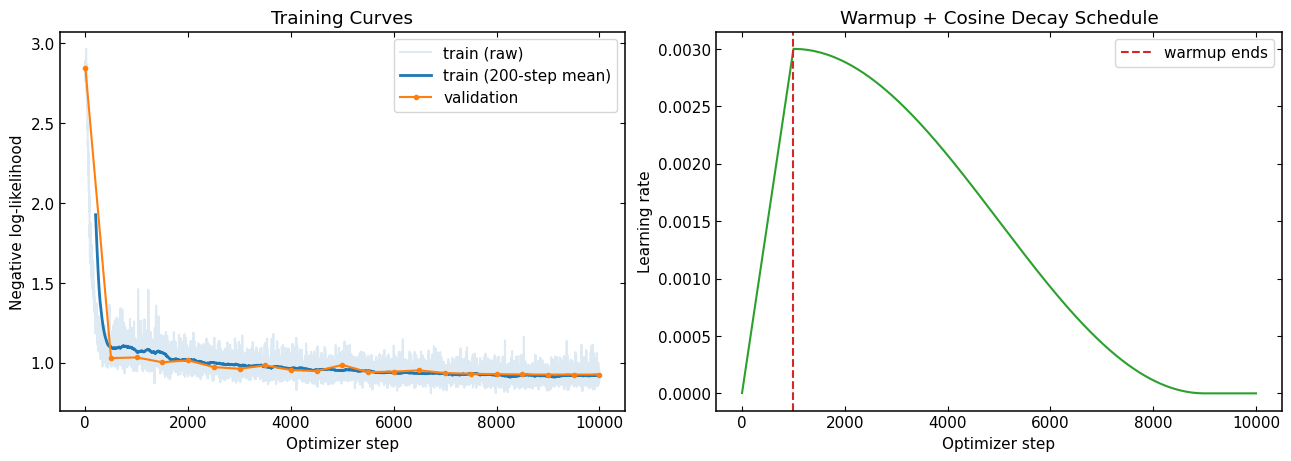

In [4]:
HIDDEN_FEATURES = (128, 128, 128)
NUM_BINS = 16
TRAIN_STEPS = 10_000
BATCH_SIZE = 1_024
LEARNING_RATE = 3.0e-3
WEIGHT_DECAY = 1e-4
LR_WARMUP_FRACTION = 0.10
VAL_BATCH_SIZE = 4_096
VAL_EVERY = 500
SAMPLING_SEED = 321

learning_rate_schedule, warmup_steps, cosine_steps = make_learning_rate_schedule(
    learning_rate=LEARNING_RATE,
    train_steps=TRAIN_STEPS,
    warmup_fraction=LR_WARMUP_FRACTION,
)

model = ConditionalAutoregressiveSplineFlow(
    num_bins=NUM_BINS,
    hidden_features=HIDDEN_FEATURES,
    bound=6.0,
)

rng = jax.random.PRNGKey(7)
rng, init_rng = jax.random.split(rng)

initial_params = model.init(
    init_rng,
    jnp.ones((1, train_array.shape[1]), dtype=jnp.float32),
    jnp.ones((1, train_condition_array.shape[1]), dtype=jnp.float32),
)["params"]

state = train_state.TrainState.create(
    apply_fn=model.apply,
    params=initial_params,
    tx=optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(learning_rate=learning_rate_schedule, weight_decay=WEIGHT_DECAY),
    ),
)


def log_prob_standardized(params, x, c):
    z, logabsdet = model.apply({"params": params}, x, c)
    log_base = -0.5 * (jnp.sum(z**2, axis=-1) + x.shape[-1] * LOG_2PI)
    return log_base + logabsdet


@jax.jit
def eval_batch(params, x, c):
    return -jnp.mean(log_prob_standardized(params, x, c))


@jax.jit
def train_step(state, x, c):
    def loss_fn(params):
        return -jnp.mean(log_prob_standardized(params, x, c))

    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss


def estimate_validation_nll(
    params,
    x_val: np.ndarray,
    c_val: np.ndarray,
    batch_size: int = VAL_BATCH_SIZE,
) -> float:
    losses = []
    for batch_start in range(0, len(x_val), batch_size):
        batch_stop = min(batch_start + batch_size, len(x_val))
        x_batch = jnp.asarray(x_val[batch_start:batch_stop])
        c_batch = jnp.asarray(c_val[batch_start:batch_stop])
        losses.append(float(eval_batch(params, x_batch, c_batch)))
    return float(np.mean(losses))


@jax.jit
def sample_standardized(params, key, c):
    z = jax.random.normal(key, shape=(c.shape[0], train_array.shape[1]), dtype=jnp.float32)
    x, _ = model.apply(
        {"params": params},
        z,
        c,
        method=ConditionalAutoregressiveSplineFlow.forward,
    )
    return x


history = {
    "step": [],
    "train_nll": [],
    "val_step": [],
    "val_nll": [],
    "lr": [],
}

batch_rng = np.random.default_rng(7)
best_val_nll = float("inf")
best_step = None
best_params = state.params

print(f"Model:                  {type(model).__name__}")
print(f"Trainable parameters:   {count_parameters(state.params):,}")
print(f"Batch size:             {BATCH_SIZE}")
print(f"Train steps:            {TRAIN_STEPS}")
print(f"Warmup steps:           {warmup_steps}")
print(f"Cosine-decay steps:     {cosine_steps}")
print(f"Validation every:       {VAL_EVERY}")

t0 = time.time()
progress = tqdm(range(1, TRAIN_STEPS + 1), desc="Training", leave=False)
for step in progress:
    batch_idx = batch_rng.integers(0, len(train_array), size=BATCH_SIZE)
    x_batch = jnp.asarray(train_array[batch_idx])
    c_batch = jnp.asarray(train_condition_array[batch_idx])

    state, loss = train_step(state, x_batch, c_batch)

    loss_value = float(loss)
    lr_value = float(learning_rate_schedule(int(state.step)))

    history["step"].append(step)
    history["train_nll"].append(loss_value)
    history["lr"].append(lr_value)

    if step == 1 or step % VAL_EVERY == 0 or step == TRAIN_STEPS:
        val_nll = estimate_validation_nll(
            state.params,
            val_array,
            val_condition_array,
        )
        history["val_step"].append(step)
        history["val_nll"].append(val_nll)

        if val_nll < best_val_nll:
            best_val_nll = val_nll
            best_step = step
            best_params = jax.tree_util.tree_map(lambda x: x.copy(), state.params)

        progress.set_postfix(train=f"{loss_value:.4f}", val=f"{val_nll:.4f}", lr=f"{lr_value:.2e}")
    elif step % 50 == 0:
        progress.set_postfix(train=f"{loss_value:.4f}", lr=f"{lr_value:.2e}")

elapsed = time.time() - t0
print()
print(f"Training time:          {elapsed:.2f} s")
print(f"Best validation step:   {best_step}")
print(f"Best validation NLL:    {best_val_nll:.5f}")

steps = np.asarray(history["step"])
train_nll = np.asarray(history["train_nll"])
val_steps = np.asarray(history["val_step"])
val_nll = np.asarray(history["val_nll"])
learning_rates = np.asarray(history["lr"])

smooth_window = min(200, len(train_nll))
if smooth_window > 1:
    smooth_kernel = np.ones(smooth_window, dtype=np.float64) / smooth_window
    train_nll_smooth = np.convolve(train_nll, smooth_kernel, mode="valid")
    smooth_steps = steps[smooth_window - 1 :]
else:
    train_nll_smooth = train_nll
    smooth_steps = steps

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.5), constrained_layout=True)

axes[0].plot(steps, train_nll, color="tab:blue", alpha=0.15, label="train (raw)")
axes[0].plot(
    smooth_steps,
    train_nll_smooth,
    color="tab:blue",
    linewidth=2,
    label=f"train ({smooth_window}-step mean)",
)
axes[0].plot(val_steps, val_nll, color="tab:orange", marker="o", markersize=3, label="validation")
axes[0].set_xlabel("Optimizer step")
axes[0].set_ylabel("Negative log-likelihood")
axes[0].set_title("Training Curves")
axes[0].legend()

axes[1].plot(steps, learning_rates, color="tab:green")
axes[1].axvline(warmup_steps, color="tab:red", linestyle="--", linewidth=1.5, label="warmup ends")
axes[1].set_xlabel("Optimizer step")
axes[1].set_ylabel("Learning rate")
axes[1].set_title("Warmup + Cosine Decay Schedule")
axes[1].legend()

plt.show()


## Visual validation

We choose one held-out validation population, keep its `(log_tau, feh)` fixed, and generate a synthetic CMD from the learned conditional normalizing flow.


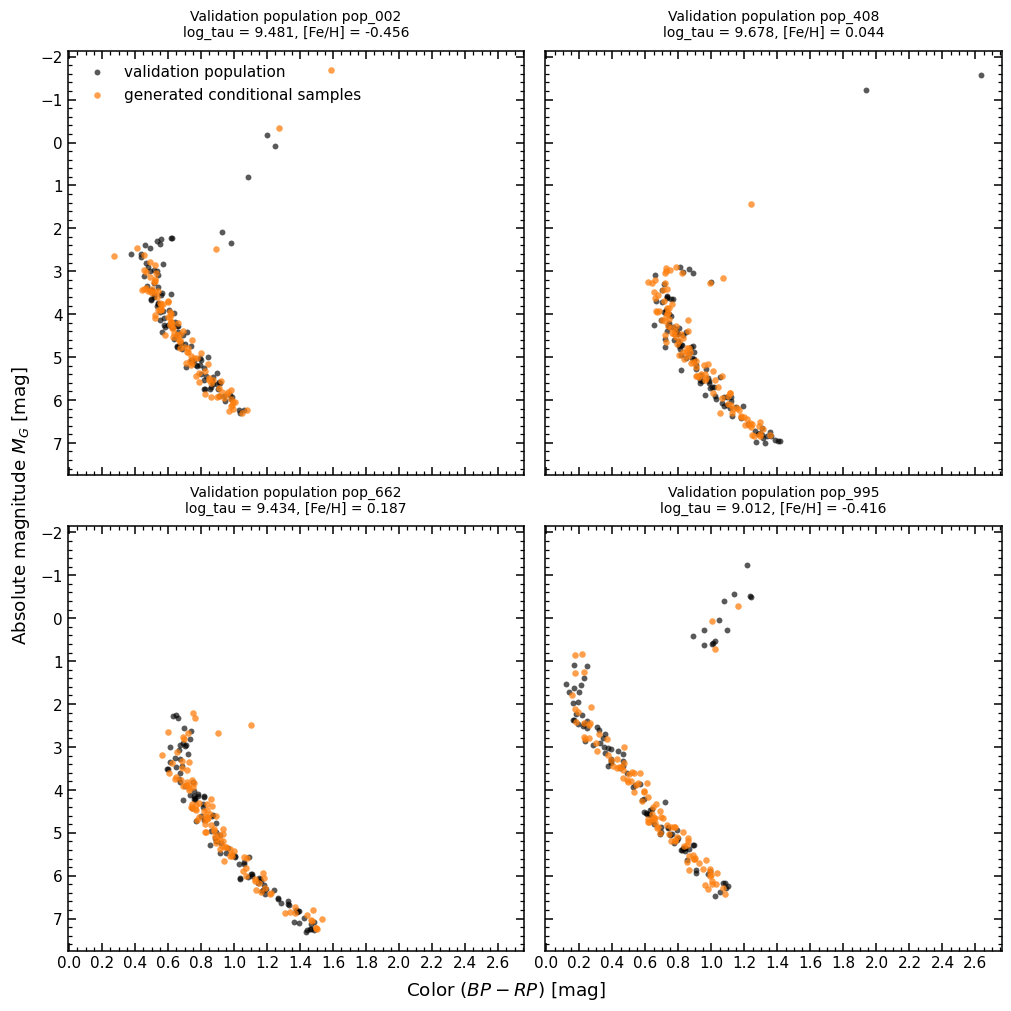

In [5]:
HELDOUT_POPULATION_COUNT = min(4, len(val_population_ids))
heldout_population_positions = np.linspace(
    0,
    len(val_population_ids) - 1,
    num=HELDOUT_POPULATION_COUNT,
    dtype=int,
)
heldout_population_ids = val_population_ids[heldout_population_positions]

params_for_sampling = best_params if best_step is not None else state.params
sampling_keys = jax.random.split(jax.random.PRNGKey(SAMPLING_SEED), HELDOUT_POPULATION_COUNT)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 10),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for panel_index, ax in enumerate(np.ravel(axes)):
    if panel_index >= HELDOUT_POPULATION_COUNT:
        ax.axis("off")
        continue

    heldout_population_id = int(heldout_population_ids[panel_index])
    heldout_population_label = f"pop_{heldout_population_id:0{population_id_width}d}"
    heldout_population_mask = population_id == heldout_population_id

    heldout_cmd = cmd_observed[heldout_population_mask]
    heldout_condition = conditioning[heldout_population_mask][0]
    heldout_condition_standardized = ((heldout_condition - cond_mean) / cond_std).astype(np.float32)

    heldout_condition_batch = np.repeat(
        heldout_condition_standardized[None, :],
        len(heldout_cmd),
        axis=0,
    ).astype(np.float32)

    generated_standardized = np.asarray(
        sample_standardized(
            params_for_sampling,
            sampling_keys[panel_index],
            jnp.asarray(heldout_condition_batch),
        )
    )
    generated_cmd = (generated_standardized * x_std + x_mean).astype(np.float32)

    ax.scatter(
        heldout_cmd[:, CMD_COLOR_COLUMN],
        heldout_cmd[:, CMD_GMAG_COLUMN],
        s=18,
        alpha=0.65,
        color="black",
        linewidths=0,
        label="validation population",
        rasterized=True,
    )
    ax.scatter(
        generated_cmd[:, CMD_COLOR_COLUMN],
        generated_cmd[:, CMD_GMAG_COLUMN],
        s=22,
        alpha=0.75,
        color="tab:orange",
        linewidths=0,
        label="generated conditional samples",
        rasterized=True,
    )

    ax.set_title(
        (
            f"Validation population {heldout_population_label}\n"
            f"log_tau = {heldout_condition[LOG_TAU_COLUMN]:.3f}, [Fe/H] = {heldout_condition[FEH_COLUMN]:.3f}"
        ),
        pad=10,
        fontsize=10,
    )

    ax.grid(False)
    ax.xaxis.set_major_locator(MultipleLocator(0.2))
    ax.xaxis.set_minor_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_locator(MultipleLocator(1.0))
    ax.yaxis.set_minor_locator(MultipleLocator(0.2))
    ax.tick_params(which="major", length=6, width=1.1)
    ax.tick_params(which="minor", length=3, width=0.9)
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)

axes[0, 0].invert_yaxis()   # do this once only
axes[0, 0].legend(loc="upper left", frameon=False)
fig.supxlabel(r"Color $(BP - RP)$ [mag]")
fig.supylabel(r"Absolute magnitude $M_G$ [mag]")

plt.show()


## Log-likelihood evaluation on a 2D grid

Because the hyperparameter space is two-dimensional, we can afford a dense grid evaluation of the log-likelihood. We apply this to the cluster generated for last week’s unconditional Flow Matching test, but by default condition on only 1,000 stars rather than all 300,000.

Single-population path:     tutorial_data/tutorial_single_population.npz
Full cluster size:          300,000
Evaluation subset size:     1,000
Single-population seed:     7
True log(age / yr):         9.400
True [Fe/H]:                -0.250
Grid max log(age / yr):     9.392
Grid max [Fe/H]:            -0.240


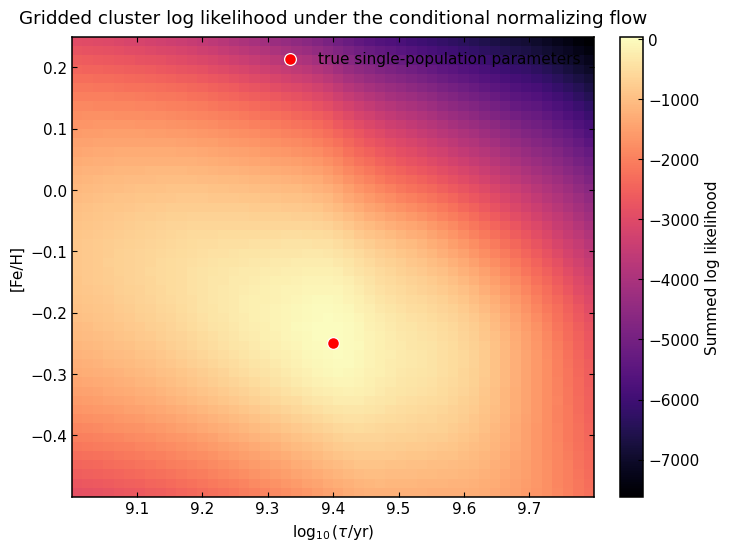

In [6]:
SINGLE_POPULATION_PATH = ROOT / "tutorial_data" / "tutorial_single_population.npz"
SINGLE_SOURCE_REQUIRED_COLUMNS = ("G", "BR", "RP")
GRID_SIZE = 50
EVAL_CLUSTER_SIZE = 1000
CONDITION_BATCH_SIZE = 16
STAR_BATCH_SIZE = 8_192

single_catalog = np.load(SINGLE_POPULATION_PATH)
single_raw_data = single_catalog["data"].astype(np.float32)
single_raw_columns = tuple(str(name) for name in single_catalog["columns"].tolist())
single_log_tau_true = float(single_catalog["log_tau"])
single_feh_true = float(single_catalog["feh"])
single_sample_seed = int(single_catalog["sample_seed"])

single_column_to_index = {name: idx for idx, name in enumerate(single_raw_columns)}
missing_single_columns = [
    name for name in SINGLE_SOURCE_REQUIRED_COLUMNS if name not in single_column_to_index
]
if missing_single_columns:
    raise ValueError(f"Missing required single-population columns: {missing_single_columns}")

single_g_clean = single_raw_data[:, single_column_to_index["G"]]
single_br_clean = single_raw_data[:, single_column_to_index["BR"]]
single_rp_clean = single_raw_data[:, single_column_to_index["RP"]]
single_bp_clean = (single_br_clean + single_rp_clean).astype(np.float32)

# Rebuild the observed cluster CMD exactly as in FM_single_population_of_stars.ipynb.
single_noise_rng = np.random.default_rng(OBSERVATION_NOISE_SEED)
single_noise_g = single_noise_rng.normal(
    loc=OBSERVATION_NOISE_MEAN,
    scale=OBSERVATION_NOISE_STD,
    size=len(single_raw_data),
).astype(np.float32)
single_noise_bp = single_noise_rng.normal(
    loc=OBSERVATION_NOISE_MEAN,
    scale=OBSERVATION_NOISE_STD,
    size=len(single_raw_data),
).astype(np.float32)
single_noise_rp = single_noise_rng.normal(
    loc=OBSERVATION_NOISE_MEAN,
    scale=OBSERVATION_NOISE_STD,
    size=len(single_raw_data),
).astype(np.float32)

single_g_obs = (single_g_clean + single_noise_g).astype(np.float32)
single_bp_obs = (single_bp_clean + single_noise_bp).astype(np.float32)
single_rp_obs = (single_rp_clean + single_noise_rp).astype(np.float32)
single_bp_rp_obs = (single_bp_obs - single_rp_obs).astype(np.float32)
single_cmd_observed = np.column_stack([single_bp_rp_obs, single_g_obs]).astype(np.float32)

eval_cluster_size = min(EVAL_CLUSTER_SIZE, len(single_cmd_observed))
eval_cluster_rng = np.random.default_rng(single_sample_seed)
eval_cluster_idx = np.sort(
    eval_cluster_rng.choice(len(single_cmd_observed), size=eval_cluster_size, replace=False)
)
single_cmd_eval = single_cmd_observed[eval_cluster_idx]

min_logage = float(population_log_tau.min())
max_logage = float(population_log_tau.max())
min_feh = float(population_feh.min())
max_feh = float(population_feh.max())

grid_logage = np.linspace(min_logage, max_logage, GRID_SIZE, dtype=np.float32)
grid_feh = np.linspace(min_feh, max_feh, GRID_SIZE, dtype=np.float32)
grid_logage_mesh, grid_feh_mesh = np.meshgrid(grid_logage, grid_feh, indexing="xy")
grid_conditions = np.column_stack(
    [grid_logage_mesh.ravel(), grid_feh_mesh.ravel()]
).astype(np.float32)
grid_conditions_standardized = ((grid_conditions - cond_mean) / cond_std).astype(np.float32)

x_mean_jnp = jnp.asarray(x_mean, dtype=jnp.float32)
x_std_jnp = jnp.asarray(x_std, dtype=jnp.float32)
log_x_scale_correction = jnp.sum(jnp.log(x_std_jnp))
params_for_grid = best_params if best_step is not None else state.params


@jax.jit
def cluster_loglik_condition_chunk(params, x_obs_batch, c_std_chunk):
    x_obs_batch = jnp.asarray(x_obs_batch, dtype=jnp.float32)
    c_std_chunk = jnp.asarray(c_std_chunk, dtype=jnp.float32)

    x_std_batch = (x_obs_batch - x_mean_jnp) / x_std_jnp
    batch_size = x_std_batch.shape[0]

    def one_condition(c_std):
        c_batch = jnp.broadcast_to(c_std, (batch_size, c_std.shape[0]))
        log_prob_std = log_prob_standardized(params, x_std_batch, c_batch)
        return jnp.sum(log_prob_std) - batch_size * log_x_scale_correction

    return jax.vmap(one_condition)(c_std_chunk)


grid_loglik_flat = np.zeros(len(grid_conditions), dtype=np.float64)

condition_starts = range(0, len(grid_conditions_standardized), CONDITION_BATCH_SIZE)
for cond_start in tqdm(condition_starts, desc="Likelihood grid", leave=False):
    cond_stop = min(cond_start + CONDITION_BATCH_SIZE, len(grid_conditions_standardized))
    c_std_chunk = grid_conditions_standardized[cond_start:cond_stop]
    chunk_loglik = np.zeros(len(c_std_chunk), dtype=np.float64)

    for star_start in range(0, len(single_cmd_eval), STAR_BATCH_SIZE):
        star_stop = min(star_start + STAR_BATCH_SIZE, len(single_cmd_eval))
        x_obs_batch = single_cmd_eval[star_start:star_stop]
        chunk_loglik += np.asarray(
            cluster_loglik_condition_chunk(params_for_grid, x_obs_batch, c_std_chunk),
            dtype=np.float64,
        )

    grid_loglik_flat[cond_start:cond_stop] = chunk_loglik

grid_loglik = grid_loglik_flat.reshape(len(grid_feh), len(grid_logage))
best_grid_index = int(np.argmax(grid_loglik_flat))
best_logage = float(grid_conditions[best_grid_index, LOG_TAU_COLUMN])
best_feh = float(grid_conditions[best_grid_index, FEH_COLUMN])

print(f"Single-population path:     {SINGLE_POPULATION_PATH.relative_to(ROOT)}")
print(f"Full cluster size:          {len(single_cmd_observed):,}")
print(f"Evaluation subset size:     {len(single_cmd_eval):,}")
print(f"Single-population seed:     {single_sample_seed}")
print(f"True log(age / yr):         {single_log_tau_true:.3f}")
print(f"True [Fe/H]:                {single_feh_true:.3f}")
print(f"Grid max log(age / yr):     {best_logage:.3f}")
print(f"Grid max [Fe/H]:            {best_feh:.3f}")

fig, ax = plt.subplots(figsize=(7.2, 5.4), constrained_layout=True)

im = ax.imshow(
    grid_loglik,
    extent=(grid_logage.min(), grid_logage.max(), grid_feh.min(), grid_feh.max()),
    origin="lower",
    aspect="auto",
    cmap="magma",
    interpolation="nearest",
)
ax.scatter(
    [single_log_tau_true],
    [single_feh_true],
    s=72,
    color="red",
    edgecolors="white",
    linewidths=0.9,
    label="true single-population parameters",
)

ax.set_xlabel(r"$\log_{10}(\tau / \mathrm{yr})$")
ax.set_ylabel(r"[Fe/H]")
ax.set_title("Gridded cluster log likelihood under the conditional normalizing flow", pad=10)
ax.legend(frameon=False, loc="upper right")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Summed log likelihood")

plt.show()


## Run MCMC with the Metropolis algorithm

After training the normalizing flow, we use MCMC to sample from the posterior, since the model provides straightforward access to the amortized likelihood.

Random-search evaluations:   100
MCMC steps:                  2000
Burn-in:                     200
Thinning:                    every 10 samples
Proposal std (log_age, feh): [0.01 0.01]
Acceptance rate:             0.188
Posterior draws after burn-in: 1800
Thinned posterior draws:       180

True log(age / yr):          9.400
True [Fe/H]:                 -0.250

Initial log(age / yr):       9.397
Initial [Fe/H]:              -0.223
Initial log posterior:       27.464

Posterior mean log(age):     9.399
Posterior mean [Fe/H]:       -0.240


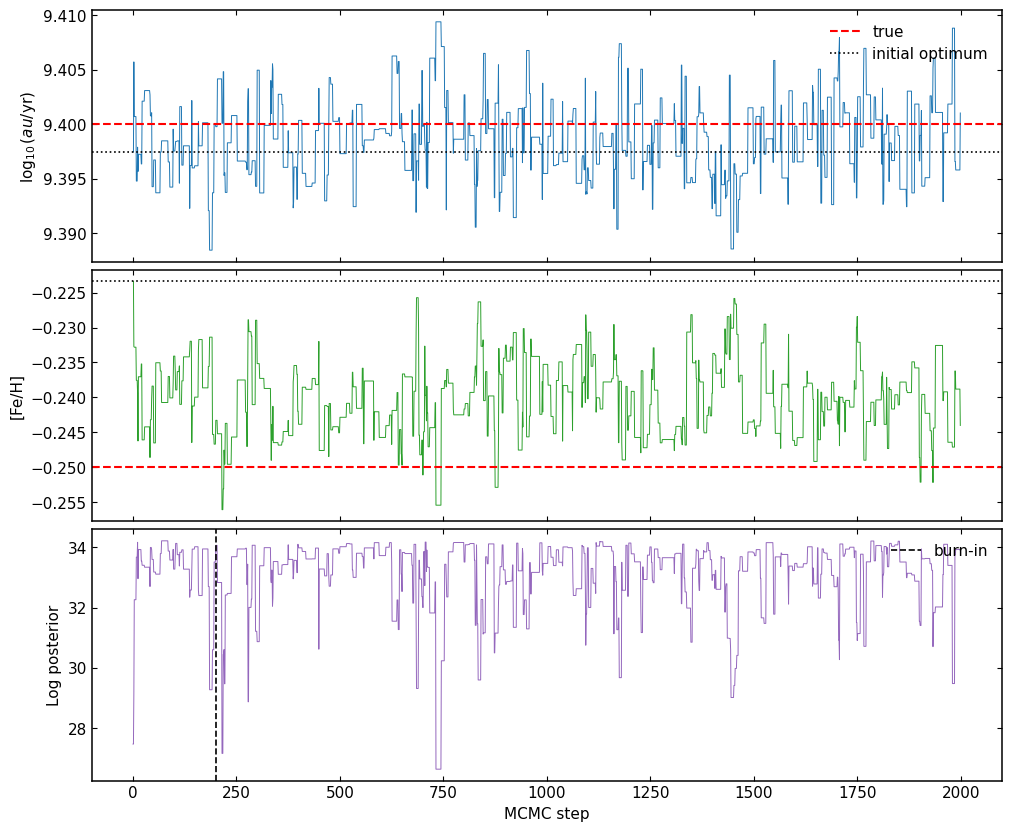

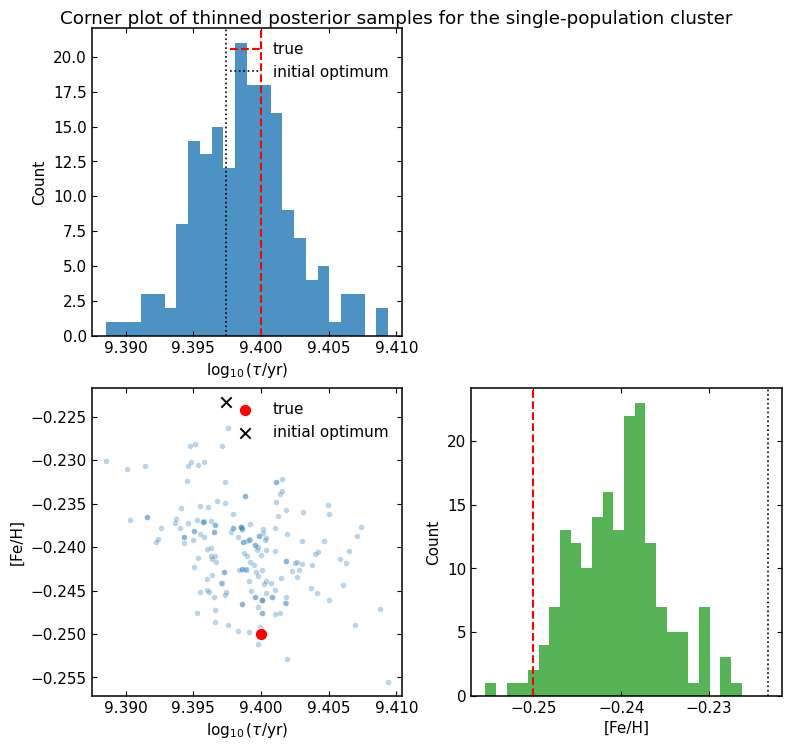

In [7]:

MCMC_RANDOM_EVALS = 100
MCMC_STEPS = 2_000
MCMC_BURN_IN = 200
MCMC_THIN = 10
MCMC_SEED = 2025
MCMC_PROPOSAL_STD = np.asarray([0.01, 0.01], dtype=np.float32)
CORNER_BINS = 24

single_cmd_eval_jnp = jnp.asarray(single_cmd_eval, dtype=jnp.float32)


def conditions_inside_box(conditions):
    conditions = np.asarray(conditions, dtype=np.float32)
    return (
        (conditions[..., LOG_TAU_COLUMN] >= min_logage)
        & (conditions[..., LOG_TAU_COLUMN] <= max_logage)
        & (conditions[..., FEH_COLUMN] >= min_feh)
        & (conditions[..., FEH_COLUMN] <= max_feh)
    )


def clip_conditions_to_box(conditions):
    clipped = np.asarray(conditions, dtype=np.float32).copy()
    clipped[..., LOG_TAU_COLUMN] = np.clip(
        clipped[..., LOG_TAU_COLUMN],
        min_logage,
        max_logage,
    )
    clipped[..., FEH_COLUMN] = np.clip(
        clipped[..., FEH_COLUMN],
        min_feh,
        max_feh,
    )
    return clipped.astype(np.float32)


def log_uniform_box_prior(condition):
    inside = bool(conditions_inside_box(np.asarray(condition, dtype=np.float32)))
    return 0.0 if inside else -np.inf


@jax.jit
def cluster_loglik_one_condition(params, x_obs, c_std):
    x_obs = jnp.asarray(x_obs, dtype=jnp.float32)
    c_std = jnp.asarray(c_std, dtype=jnp.float32)

    x_std_batch = (x_obs - x_mean_jnp) / x_std_jnp
    c_batch = jnp.broadcast_to(c_std, (x_std_batch.shape[0], c_std.shape[0]))
    log_prob_std = log_prob_standardized(params, x_std_batch, c_batch)
    return jnp.sum(log_prob_std) - x_std_batch.shape[0] * log_x_scale_correction


def evaluate_log_posterior_for_cluster(
    x_obs,
    condition,
    *,
    params=params_for_grid,
):
    log_prior = log_uniform_box_prior(condition)
    if not np.isfinite(log_prior):
        return -np.inf

    safe_condition = clip_conditions_to_box(condition)
    c_std = ((safe_condition - cond_mean) / cond_std).astype(np.float32)
    log_likelihood = float(
        cluster_loglik_one_condition(
            params,
            x_obs,
            jnp.asarray(c_std, dtype=jnp.float32),
        )
    )
    return log_prior + log_likelihood


def evaluate_log_posterior_batch_for_cluster(
    x_obs,
    conditions,
    *,
    params=params_for_grid,
    condition_batch_size=CONDITION_BATCH_SIZE,
):
    conditions = np.asarray(conditions, dtype=np.float32)
    inside = conditions_inside_box(conditions)
    safe_conditions = clip_conditions_to_box(conditions)
    c_std_all = ((safe_conditions - cond_mean) / cond_std).astype(np.float32)

    log_posterior = np.empty(len(conditions), dtype=np.float64)
    for cond_start in range(0, len(c_std_all), condition_batch_size):
        cond_stop = min(cond_start + condition_batch_size, len(c_std_all))
        c_std_chunk = c_std_all[cond_start:cond_stop]
        log_posterior[cond_start:cond_stop] = np.asarray(
            cluster_loglik_condition_chunk(params, x_obs, c_std_chunk),
            dtype=np.float64,
        )

    log_posterior[~inside] = -np.inf
    return log_posterior


def thin_mcmc_samples(chain, burn_in, thin):
    if burn_in >= len(chain):
        raise ValueError("Burn-in must be smaller than the number of MCMC steps.")
    if thin <= 0:
        raise ValueError("Thinning factor must be positive.")
    return np.asarray(chain[burn_in::thin], dtype=np.float32)


def plot_corner_like(
    samples,
    true_condition,
    initial_condition,
    *,
    bins=CORNER_BINS,
):
    labels = [r"$\log_{10}(\tau / \mathrm{yr})$", r"[Fe/H]"]
    true_condition = np.asarray(true_condition, dtype=np.float32)
    initial_condition = np.asarray(initial_condition, dtype=np.float32)

    fig, axes = plt.subplots(2, 2, figsize=(7.8, 7.2), constrained_layout=True)
    ax00, ax01 = axes[0]
    ax10, ax11 = axes[1]

    ax01.axis("off")

    ax00.hist(samples[:, LOG_TAU_COLUMN], bins=bins, color="tab:blue", alpha=0.80)
    ax00.axvline(
        true_condition[LOG_TAU_COLUMN],
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="true",
    )
    ax00.axvline(
        initial_condition[LOG_TAU_COLUMN],
        color="black",
        linestyle=":",
        linewidth=1.2,
        label="initial optimum",
    )
    ax00.set_xlabel(labels[LOG_TAU_COLUMN])
    ax00.set_ylabel("Count")
    ax00.legend(frameon=False, loc="upper right")

    ax10.scatter(
        samples[:, LOG_TAU_COLUMN],
        samples[:, FEH_COLUMN],
        s=16,
        alpha=0.30,
        color="tab:blue",
        linewidths=0,
    )
    ax10.scatter(
        [true_condition[LOG_TAU_COLUMN]],
        [true_condition[FEH_COLUMN]],
        s=80,
        color="red",
        edgecolors="white",
        linewidths=0.8,
        label="true",
    )
    ax10.scatter(
        [initial_condition[LOG_TAU_COLUMN]],
        [initial_condition[FEH_COLUMN]],
        s=55,
        color="black",
        marker="x",
        linewidths=1.4,
        label="initial optimum",
    )
    ax10.set_xlabel(labels[LOG_TAU_COLUMN])
    ax10.set_ylabel(labels[FEH_COLUMN])
    ax10.legend(frameon=False, loc="upper right")

    ax11.hist(samples[:, FEH_COLUMN], bins=bins, color="tab:green", alpha=0.80)
    ax11.axvline(
        true_condition[FEH_COLUMN],
        color="red",
        linestyle="--",
        linewidth=1.5,
    )
    ax11.axvline(
        initial_condition[FEH_COLUMN],
        color="black",
        linestyle=":",
        linewidth=1.2,
    )
    ax11.set_xlabel(labels[FEH_COLUMN])
    ax11.set_ylabel("Count")

    for ax in (ax00, ax10, ax11):
        ax.grid(False)

    fig.suptitle(
        "Corner plot of thinned posterior samples for the single-population cluster",
        y=1.02,
    )
    plt.show()


def run_random_start_metropolis(
    x_obs,
    *,
    rng_seed,
    random_evals,
    steps,
    burn_in,
    thin,
    proposal_std,
    params=params_for_grid,
):
    if burn_in >= steps:
        raise ValueError("Burn-in must be smaller than the number of MCMC steps.")

    x_obs_jnp = jnp.asarray(x_obs, dtype=jnp.float32)
    proposal_std = np.asarray(proposal_std, dtype=np.float32)

    mcmc_rng = np.random.default_rng(rng_seed)

    random_conditions = np.column_stack(
        [
            mcmc_rng.uniform(min_logage, max_logage, size=random_evals),
            mcmc_rng.uniform(min_feh, max_feh, size=random_evals),
        ]
    ).astype(np.float32)
    random_log_posterior = evaluate_log_posterior_batch_for_cluster(
        x_obs_jnp,
        random_conditions,
        params=params,
    )

    best_random_index = int(np.argmax(random_log_posterior))
    initial_condition = random_conditions[best_random_index].copy()
    initial_log_posterior = float(random_log_posterior[best_random_index])

    chain = np.zeros((steps, 2), dtype=np.float32)
    log_posterior_chain = np.zeros(steps, dtype=np.float64)
    accepted = np.zeros(steps, dtype=bool)

    current_condition = initial_condition.copy()
    current_log_posterior = initial_log_posterior

    for step in tqdm(range(steps), desc="MCMC", leave=False):
        proposal = (
            current_condition
            + mcmc_rng.normal(loc=0.0, scale=proposal_std, size=2).astype(np.float32)
        )
        proposal_log_posterior = evaluate_log_posterior_for_cluster(
            x_obs_jnp,
            proposal,
            params=params,
        )

        log_accept_ratio = proposal_log_posterior - current_log_posterior
        if np.log(mcmc_rng.uniform()) < np.minimum(0.0, log_accept_ratio):
            current_condition = proposal
            current_log_posterior = proposal_log_posterior
            accepted[step] = True

        chain[step] = current_condition
        log_posterior_chain[step] = current_log_posterior

    posterior_samples = np.asarray(chain[burn_in:], dtype=np.float32)
    posterior_samples_thinned = thin_mcmc_samples(chain, burn_in, thin)

    return {
        "chain": chain,
        "log_posterior_chain": log_posterior_chain,
        "accepted": accepted,
        "acceptance_rate": float(np.mean(accepted)),
        "initial_condition": initial_condition,
        "initial_log_posterior": initial_log_posterior,
        "posterior_samples": posterior_samples,
        "posterior_samples_thinned": posterior_samples_thinned,
    }


single_mcmc_results = run_random_start_metropolis(
    single_cmd_eval_jnp,
    rng_seed=MCMC_SEED,
    random_evals=MCMC_RANDOM_EVALS,
    steps=MCMC_STEPS,
    burn_in=MCMC_BURN_IN,
    thin=MCMC_THIN,
    proposal_std=MCMC_PROPOSAL_STD,
    params=params_for_grid,
)

chain = single_mcmc_results["chain"]
log_posterior_chain = single_mcmc_results["log_posterior_chain"]
accepted = single_mcmc_results["accepted"]
acceptance_rate = float(single_mcmc_results["acceptance_rate"])
initial_condition = np.asarray(single_mcmc_results["initial_condition"], dtype=np.float32)
initial_log_posterior = float(single_mcmc_results["initial_log_posterior"])
posterior_samples = np.asarray(single_mcmc_results["posterior_samples"], dtype=np.float32)
posterior_samples_thinned = np.asarray(
    single_mcmc_results["posterior_samples_thinned"],
    dtype=np.float32,
)

print(f"Random-search evaluations:   {MCMC_RANDOM_EVALS}")
print(f"MCMC steps:                  {MCMC_STEPS}")
print(f"Burn-in:                     {MCMC_BURN_IN}")
print(f"Thinning:                    every {MCMC_THIN} samples")
print(f"Proposal std (log_age, feh): {MCMC_PROPOSAL_STD}")
print(f"Acceptance rate:             {acceptance_rate:.3f}")
print(f"Posterior draws after burn-in: {len(posterior_samples)}")
print(f"Thinned posterior draws:       {len(posterior_samples_thinned)}")
print()
print(f"True log(age / yr):          {single_log_tau_true:.3f}")
print(f"True [Fe/H]:                 {single_feh_true:.3f}")
print()
print(f"Initial log(age / yr):       {initial_condition[LOG_TAU_COLUMN]:.3f}")
print(f"Initial [Fe/H]:              {initial_condition[FEH_COLUMN]:.3f}")
print(f"Initial log posterior:       {initial_log_posterior:.3f}")
print()
print(f"Posterior mean log(age):     {posterior_samples_thinned[:, LOG_TAU_COLUMN].mean():.3f}")
print(f"Posterior mean [Fe/H]:       {posterior_samples_thinned[:, FEH_COLUMN].mean():.3f}")

mcmc_steps_axis = np.arange(MCMC_STEPS)

fig, axes = plt.subplots(3, 1, figsize=(10.0, 8.2), sharex=True, constrained_layout=True)

axes[0].plot(mcmc_steps_axis, chain[:, LOG_TAU_COLUMN], color="tab:blue", linewidth=0.7)
axes[0].axhline(single_log_tau_true, color="red", linestyle="--", linewidth=1.5, label="true")
axes[0].axhline(initial_condition[LOG_TAU_COLUMN], color="black", linestyle=":", linewidth=1.2, label="initial optimum")
axes[0].set_ylabel(r"$\log_{10}(	au / \mathrm{yr})$")
axes[0].legend(frameon=False, loc="upper right")

axes[1].plot(mcmc_steps_axis, chain[:, FEH_COLUMN], color="tab:green", linewidth=0.7)
axes[1].axhline(single_feh_true, color="red", linestyle="--", linewidth=1.5)
axes[1].axhline(initial_condition[FEH_COLUMN], color="black", linestyle=":", linewidth=1.2)
axes[1].set_ylabel(r"[Fe/H]")

axes[2].plot(mcmc_steps_axis, log_posterior_chain, color="tab:purple", linewidth=0.7)
axes[2].axvline(MCMC_BURN_IN, color="black", linestyle="--", linewidth=1.2, label="burn-in")
axes[2].set_xlabel("MCMC step")
axes[2].set_ylabel("Log posterior")
axes[2].legend(frameon=False, loc="upper right")

for ax in axes:
    ax.grid(False)

plt.show()

plot_corner_like(
    posterior_samples_thinned,
    np.asarray([single_log_tau_true, single_feh_true], dtype=np.float32),
    initial_condition,
)


## Estimate posteriors for all validation examples

The validation dataset consists of 100 simple stellar populations excluded from training. We run posterior sampling for each of them to evaluate the calibration of the normalizing flow.

Validation populations:          100
Stars per validation cluster:    100 .. 100
Random-search evaluations:       100
MCMC steps per cluster:          2000
Warm-up discarded:               200
Thinning:                        every 10 samples
Posterior samples per cluster:   180
Mean acceptance rate:            0.586
Median acceptance rate:          0.591

RMSE of posterior means, log(age): 0.0164
RMSE of posterior means, [Fe/H]:   0.0158


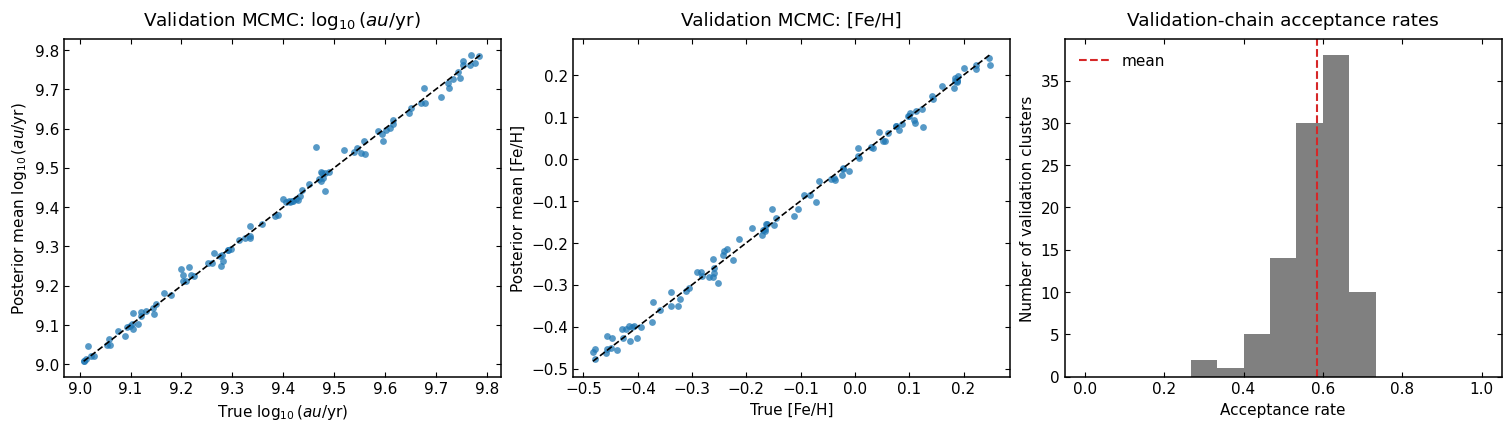

In [8]:

VALIDATION_MCMC_RANDOM_EVALS = 100
VALIDATION_MCMC_STEPS = 2_000
VALIDATION_MCMC_BURN_IN = 200
VALIDATION_MCMC_THIN = 10
VALIDATION_MCMC_SEED = 31_415
VALIDATION_MCMC_PROPOSAL_STD = MCMC_PROPOSAL_STD.copy()

selected_val_population_ids = np.asarray(val_population_ids, dtype=np.int32)
population_to_table_index = {int(pid): idx for idx, pid in enumerate(unique_population_ids)}

validation_cmd_groups = [
    cmd_observed[population_id == pid].astype(np.float32)
    for pid in selected_val_population_ids
]
validation_star_counts = np.asarray([len(group) for group in validation_cmd_groups], dtype=np.int32)

if not np.all(validation_star_counts == validation_star_counts[0]):
    raise ValueError(
        "The validation MCMC cell expects fixed-size validation clusters for batched execution."
    )

validation_cmd_batch = np.stack(validation_cmd_groups).astype(np.float32)
validation_cmd_batch_jnp = jnp.asarray(validation_cmd_batch, dtype=jnp.float32)
validation_true_conditions = population_conditioning[
    [population_to_table_index[int(pid)] for pid in selected_val_population_ids]
].astype(np.float32)
validation_population_labels = np.asarray(
    [f"pop_{int(pid):0{population_id_width}d}" for pid in selected_val_population_ids]
)


@jax.jit
def cluster_loglik_many_population_conditions(params, x_obs_population_batch, c_std_population_batch):
    x_obs_population_batch = jnp.asarray(x_obs_population_batch, dtype=jnp.float32)
    c_std_population_batch = jnp.asarray(c_std_population_batch, dtype=jnp.float32)
    x_std_population_batch = (x_obs_population_batch - x_mean_jnp) / x_std_jnp
    n_stars = x_std_population_batch.shape[1]

    def one_population(x_std_population, c_std):
        c_batch = jnp.broadcast_to(c_std, (n_stars, c_std.shape[0]))
        log_prob_std = log_prob_standardized(params, x_std_population, c_batch)
        return jnp.sum(log_prob_std) - n_stars * log_x_scale_correction

    return jax.vmap(one_population)(x_std_population_batch, c_std_population_batch)


@jax.jit
def cluster_loglik_population_condition_grid(
    params,
    x_obs_population_batch,
    c_std_population_grid,
):
    x_obs_population_batch = jnp.asarray(x_obs_population_batch, dtype=jnp.float32)
    c_std_population_grid = jnp.asarray(c_std_population_grid, dtype=jnp.float32)
    x_std_population_batch = (x_obs_population_batch - x_mean_jnp) / x_std_jnp
    n_stars = x_std_population_batch.shape[1]

    def one_population(x_std_population, c_std_grid):
        def one_condition(c_std):
            c_batch = jnp.broadcast_to(c_std, (n_stars, c_std.shape[0]))
            log_prob_std = log_prob_standardized(params, x_std_population, c_batch)
            return jnp.sum(log_prob_std) - n_stars * log_x_scale_correction

        return jax.vmap(one_condition)(c_std_grid)

    return jax.vmap(one_population)(x_std_population_batch, c_std_population_grid)


def evaluate_population_log_posterior_batch(
    x_obs_population_batch,
    conditions,
    *,
    params=params_for_grid,
):
    conditions = np.asarray(conditions, dtype=np.float32)
    inside = conditions_inside_box(conditions)
    safe_conditions = clip_conditions_to_box(conditions)
    c_std_population_batch = ((safe_conditions - cond_mean) / cond_std).astype(np.float32)

    log_posterior = np.asarray(
        cluster_loglik_many_population_conditions(
            params,
            x_obs_population_batch,
            c_std_population_batch,
        ),
        dtype=np.float64,
    )
    log_posterior[~inside] = -np.inf
    return log_posterior


validation_rng = np.random.default_rng(VALIDATION_MCMC_SEED)
n_validation_populations = len(selected_val_population_ids)

random_conditions = np.empty(
    (n_validation_populations, VALIDATION_MCMC_RANDOM_EVALS, 2),
    dtype=np.float32,
)
random_conditions[..., LOG_TAU_COLUMN] = validation_rng.uniform(
    min_logage,
    max_logage,
    size=(n_validation_populations, VALIDATION_MCMC_RANDOM_EVALS),
)
random_conditions[..., FEH_COLUMN] = validation_rng.uniform(
    min_feh,
    max_feh,
    size=(n_validation_populations, VALIDATION_MCMC_RANDOM_EVALS),
)
random_conditions_standardized = ((random_conditions - cond_mean) / cond_std).astype(np.float32)

random_log_posterior = np.asarray(
    cluster_loglik_population_condition_grid(
        params_for_grid,
        validation_cmd_batch_jnp,
        random_conditions_standardized,
    ),
    dtype=np.float64,
)
population_indices = np.arange(n_validation_populations)
best_random_indices = np.argmax(random_log_posterior, axis=1)
initial_conditions = random_conditions[population_indices, best_random_indices].copy()
initial_log_posterior = random_log_posterior[population_indices, best_random_indices].copy()

validation_chain = np.zeros(
    (VALIDATION_MCMC_STEPS, n_validation_populations, 2),
    dtype=np.float32,
)
validation_log_posterior_chain = np.zeros(
    (VALIDATION_MCMC_STEPS, n_validation_populations),
    dtype=np.float64,
)
validation_accepted = np.zeros(
    (VALIDATION_MCMC_STEPS, n_validation_populations),
    dtype=bool,
)

current_conditions = initial_conditions.copy()
current_log_posterior = initial_log_posterior.copy()

for step in tqdm(range(VALIDATION_MCMC_STEPS), desc="Validation MCMC", leave=False):
    proposal = current_conditions + validation_rng.normal(
        loc=0.0,
        scale=VALIDATION_MCMC_PROPOSAL_STD,
        size=current_conditions.shape,
    ).astype(np.float32)
    proposal_log_posterior = evaluate_population_log_posterior_batch(
        validation_cmd_batch_jnp,
        proposal,
        params=params_for_grid,
    )

    log_accept_ratio = proposal_log_posterior - current_log_posterior
    accept = np.log(validation_rng.uniform(size=n_validation_populations)) < np.minimum(
        0.0,
        log_accept_ratio,
    )

    current_conditions[accept] = proposal[accept]
    current_log_posterior[accept] = proposal_log_posterior[accept]

    validation_chain[step] = current_conditions
    validation_log_posterior_chain[step] = current_log_posterior
    validation_accepted[step] = accept

validation_posterior_samples_thinned = np.transpose(
    validation_chain[VALIDATION_MCMC_BURN_IN::VALIDATION_MCMC_THIN],
    (1, 0, 2),
).astype(np.float32)
validation_posterior_means = validation_posterior_samples_thinned.mean(axis=1)
validation_acceptance_rates = validation_accepted.mean(axis=0).astype(np.float64)
validation_rmse = np.sqrt(
    np.mean((validation_posterior_means - validation_true_conditions) ** 2, axis=0)
)

validation_mcmc_results = {
    "population_ids": selected_val_population_ids,
    "population_labels": validation_population_labels,
    "true_conditions": validation_true_conditions,
    "initial_conditions": initial_conditions,
    "initial_log_posterior": initial_log_posterior,
    "posterior_samples_thinned": validation_posterior_samples_thinned,
    "posterior_means": validation_posterior_means,
    "acceptance_rates": validation_acceptance_rates,
    "cmd_batch": validation_cmd_batch,
    "steps": VALIDATION_MCMC_STEPS,
    "burn_in": VALIDATION_MCMC_BURN_IN,
    "thin": VALIDATION_MCMC_THIN,
    "random_evals": VALIDATION_MCMC_RANDOM_EVALS,
    "proposal_std": VALIDATION_MCMC_PROPOSAL_STD.copy(),
}

print(f"Validation populations:          {n_validation_populations}")
print(
    f"Stars per validation cluster:    "
    f"{validation_star_counts.min()} .. {validation_star_counts.max()}"
)
print(f"Random-search evaluations:       {VALIDATION_MCMC_RANDOM_EVALS}")
print(f"MCMC steps per cluster:          {VALIDATION_MCMC_STEPS}")
print(f"Warm-up discarded:               {VALIDATION_MCMC_BURN_IN}")
print(f"Thinning:                        every {VALIDATION_MCMC_THIN} samples")
print(
    "Posterior samples per cluster:   "
    f"{validation_posterior_samples_thinned.shape[1]}"
)
print(f"Mean acceptance rate:            {validation_acceptance_rates.mean():.3f}")
print(f"Median acceptance rate:          {np.median(validation_acceptance_rates):.3f}")
print()
print(f"RMSE of posterior means, log(age): {validation_rmse[LOG_TAU_COLUMN]:.4f}")
print(f"RMSE of posterior means, [Fe/H]:   {validation_rmse[FEH_COLUMN]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2), constrained_layout=True)

for ax, column, label in (
    (axes[0], LOG_TAU_COLUMN, r"$\log_{10}(	au / \mathrm{yr})$"),
    (axes[1], FEH_COLUMN, r"[Fe/H]"),
):
    truth = validation_true_conditions[:, column]
    estimate = validation_posterior_means[:, column]
    lower = float(min(truth.min(), estimate.min()))
    upper = float(max(truth.max(), estimate.max()))

    ax.scatter(truth, estimate, s=24, alpha=0.75, color="tab:blue", linewidths=0)
    ax.plot([lower, upper], [lower, upper], color="black", linestyle="--", linewidth=1.2)
    ax.set_xlabel(f"True {label}")
    ax.set_ylabel(f"Posterior mean {label}")
    ax.set_title(f"Validation MCMC: {label}", pad=10)

axes[2].hist(validation_acceptance_rates, bins=np.linspace(0.0, 1.0, 16), color="0.5")
axes[2].axvline(
    validation_acceptance_rates.mean(),
    color="tab:red",
    linestyle="--",
    linewidth=1.5,
    label="mean",
)
axes[2].set_xlabel("Acceptance rate")
axes[2].set_ylabel("Number of validation clusters")
axes[2].set_title("Validation-chain acceptance rates", pad=10)
axes[2].legend(frameon=False, loc="upper left")

for ax in axes:
    ax.grid(False)

plt.show()


## Posterior predictive checks

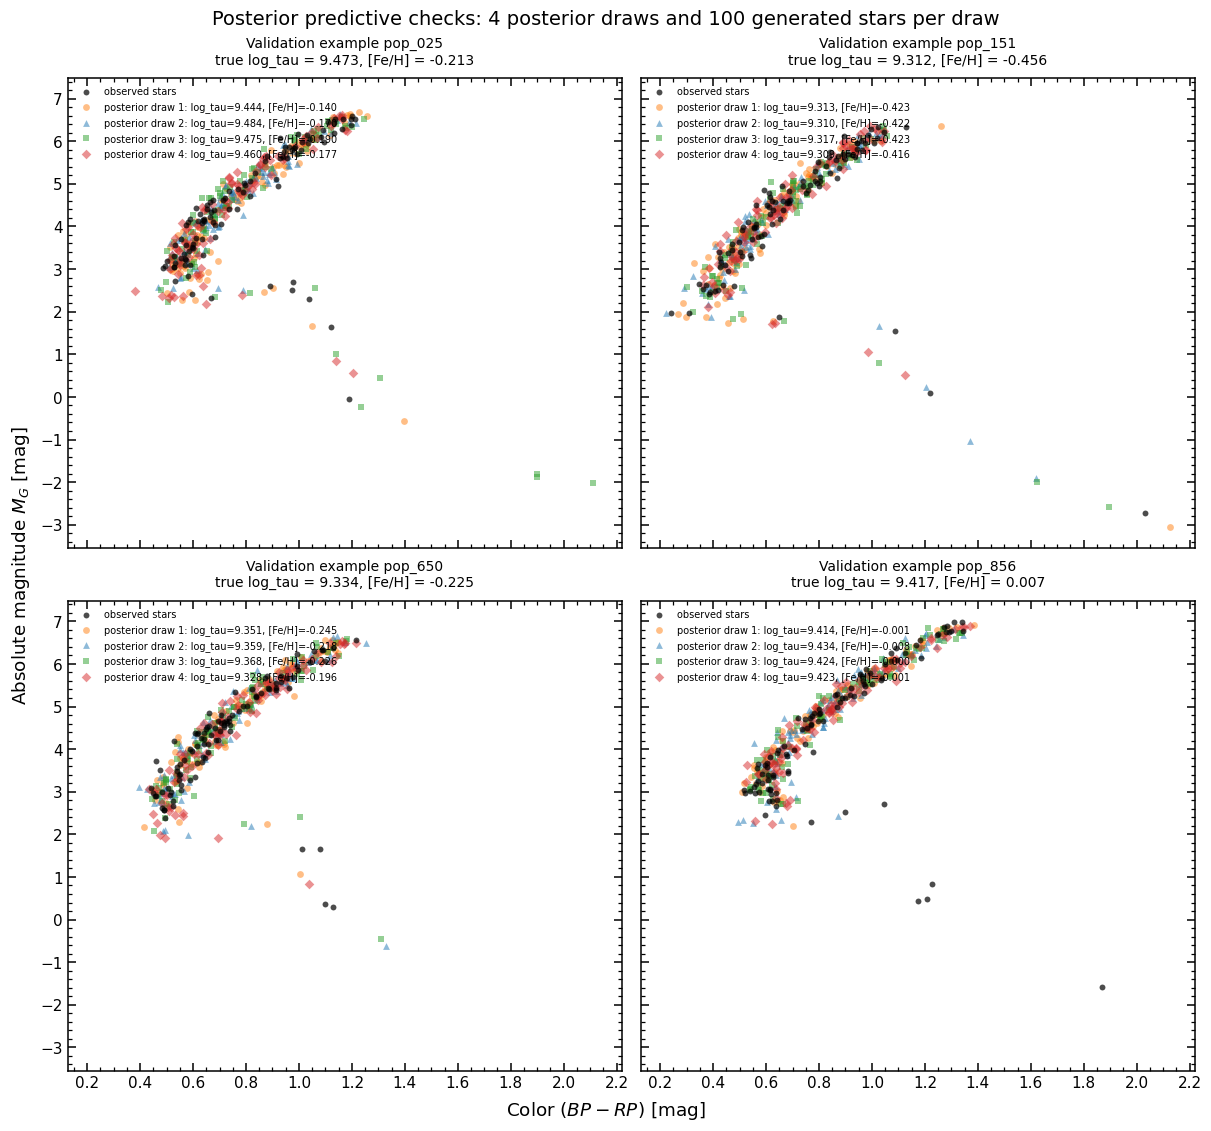

In [12]:
VALIDATION_PPC_SEED = 2026
VALIDATION_PPC_EXAMPLE_COUNT = min(4, len(validation_mcmc_results["population_ids"]))
VALIDATION_PPC_POSTERIOR_DRAW_COUNT = 4
VALIDATION_PPC_STARS_PER_DRAW = 100
VALIDATION_PPC_COLORS = ("tab:orange", "tab:blue", "tab:green", "tab:red")
VALIDATION_PPC_MARKERS = ("o", "^", "s", "D")

validation_cmd_ppc = np.asarray(validation_mcmc_results["cmd_batch"], dtype=np.float32)
validation_population_labels_ppc = np.asarray(validation_mcmc_results["population_labels"])
validation_true_conditions_ppc = np.asarray(
    validation_mcmc_results["true_conditions"],
    dtype=np.float32,
)
validation_posterior_samples_ppc = np.asarray(
    validation_mcmc_results["posterior_samples_thinned"],
    dtype=np.float32,
)

if validation_posterior_samples_ppc.shape[1] < VALIDATION_PPC_POSTERIOR_DRAW_COUNT:
    raise ValueError(
        "Posterior predictive checks require at least "
        f"{VALIDATION_PPC_POSTERIOR_DRAW_COUNT} posterior draws per validation population."
    )

ppc_rng = np.random.default_rng(VALIDATION_PPC_SEED)
selected_validation_indices = np.sort(
    ppc_rng.choice(
        len(validation_population_labels_ppc),
        size=VALIDATION_PPC_EXAMPLE_COUNT,
        replace=False,
    )
)
total_ppc_draws = VALIDATION_PPC_EXAMPLE_COUNT * VALIDATION_PPC_POSTERIOR_DRAW_COUNT
ppc_sampling_keys = jax.random.split(
    jax.random.PRNGKey(VALIDATION_PPC_SEED),
    total_ppc_draws,
)
params_for_sampling = best_params if best_step is not None else state.params

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12.0, 11.2),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = np.asarray(axes)

sampling_key_index = 0

for panel_index, ax in enumerate(axes.flat):
    if panel_index >= VALIDATION_PPC_EXAMPLE_COUNT:
        ax.axis("off")
        continue

    validation_index = int(selected_validation_indices[panel_index])
    validation_label = validation_population_labels_ppc[validation_index]
    observed_cmd = validation_cmd_ppc[validation_index]
    true_condition = validation_true_conditions_ppc[validation_index]
    posterior_samples = validation_posterior_samples_ppc[validation_index]
    selected_posterior_indices = np.sort(
        ppc_rng.choice(
            len(posterior_samples),
            size=VALIDATION_PPC_POSTERIOR_DRAW_COUNT,
            replace=False,
        )
    )

    ax.scatter(
        observed_cmd[:, CMD_COLOR_COLUMN],
        observed_cmd[:, CMD_GMAG_COLUMN],
        s=18,
        alpha=0.70,
        color="black",
        linewidths=0,
        label="observed stars",
        rasterized=True,
        zorder=10,
    )

    for draw_index, posterior_index in enumerate(selected_posterior_indices):
        posterior_condition = posterior_samples[posterior_index].astype(np.float32)
        posterior_condition_standardized = (
            (posterior_condition - cond_mean) / cond_std
        ).astype(np.float32)
        posterior_condition_batch = np.repeat(
            posterior_condition_standardized[None, :],
            VALIDATION_PPC_STARS_PER_DRAW,
            axis=0,
        ).astype(np.float32)

        generated_standardized = np.asarray(
            sample_standardized(
                params_for_sampling,
                ppc_sampling_keys[sampling_key_index],
                jnp.asarray(posterior_condition_batch),
            )
        )
        sampling_key_index += 1
        generated_cmd = (generated_standardized * x_std + x_mean).astype(np.float32)

        ax.scatter(
            generated_cmd[:, CMD_COLOR_COLUMN],
            generated_cmd[:, CMD_GMAG_COLUMN],
            s=24,
            alpha=0.50,
            color=VALIDATION_PPC_COLORS[draw_index % len(VALIDATION_PPC_COLORS)],
            marker=VALIDATION_PPC_MARKERS[draw_index % len(VALIDATION_PPC_MARKERS)],
            linewidths=0,
            zorder=5,
            label=(
                f"posterior draw {draw_index + 1}: "
                f"log_tau={posterior_condition[LOG_TAU_COLUMN]:.3f}, "
                f"[Fe/H]={posterior_condition[FEH_COLUMN]:.3f}"
            ),
            rasterized=True,
        )

    ax.set_title(
        (
            f"Validation example {validation_label}\n"
            f"true log_tau = {true_condition[LOG_TAU_COLUMN]:.3f}, [Fe/H] = {true_condition[FEH_COLUMN]:.3f}"
        ),
        pad=10,
        fontsize=10,
    )
    ax.invert_yaxis()
    ax.grid(False)
    ax.legend(loc="upper left", frameon=False, fontsize=7)
    ax.xaxis.set_major_locator(MultipleLocator(0.2))
    ax.xaxis.set_minor_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_locator(MultipleLocator(1.0))
    ax.yaxis.set_minor_locator(MultipleLocator(0.2))
    ax.tick_params(which="major", length=6, width=1.1)
    ax.tick_params(which="minor", length=3, width=0.9)
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)

fig.supxlabel(r"Color $(BP - RP)$ [mag]")
fig.supylabel(r"Absolute magnitude $M_G$ [mag]")
fig.suptitle(
    "Posterior predictive checks: 4 posterior draws and 100 generated stars per draw",
    fontsize=14,
)

plt.show()


## Inspect posterior calibration

Standard marginal SBC rank plots for the two inferred parameters.

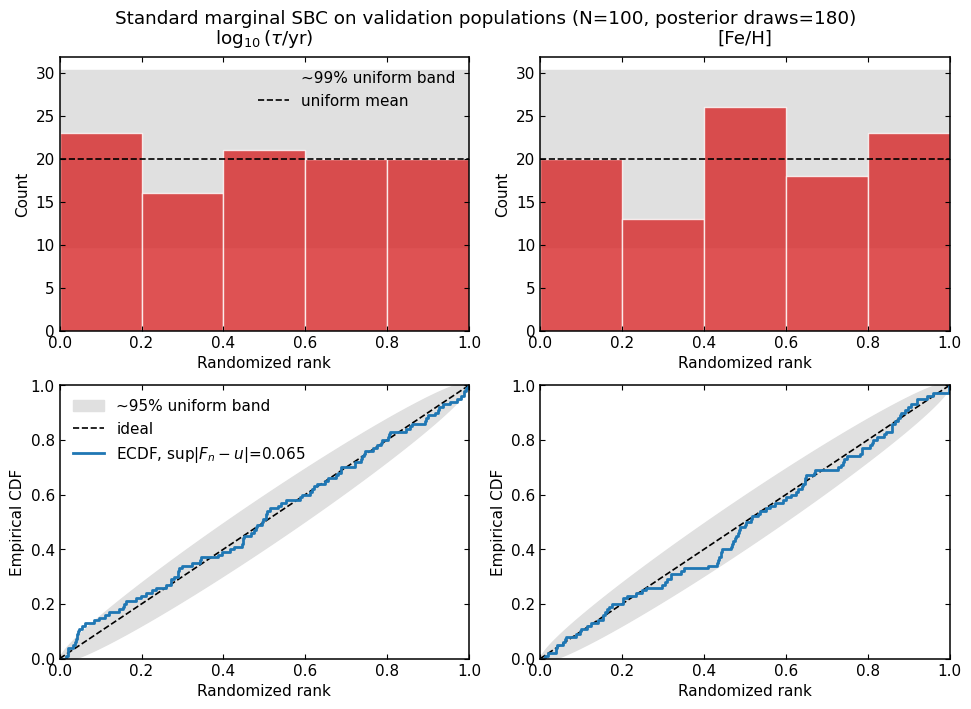

In [10]:
posterior_samples = np.asarray(
    validation_mcmc_results["posterior_samples_thinned"], dtype=np.float64
)   # shape: (n_sbc, n_draws, 2)
true_theta = np.asarray(
    validation_mcmc_results["true_conditions"], dtype=np.float64
)   # shape: (n_sbc, 2)

if posterior_samples.ndim != 3 or true_theta.ndim != 2:
    raise ValueError("Expected posterior_samples.shape = (n_sbc, n_draws, n_dim) and true_theta.shape = (n_sbc, n_dim).")
if posterior_samples.shape[0] != true_theta.shape[0]:
    raise ValueError("Mismatch in number of SBC runs between posterior samples and true parameters.")

n_sbc, n_draws, n_dim = posterior_samples.shape
labels = [r"$\log_{10}(\tau / \mathrm{yr})$", r"[Fe/H]"]
if n_dim != 2:
    labels = [f"dim {i}" for i in range(n_dim)]

# Rank of the true value among posterior draws, per dimension.
# Tie randomization is included for completeness; with continuous parameters it almost never matters.
rng = np.random.default_rng(0)
less = (posterior_samples < true_theta[:, None, :]).sum(axis=1)
equal = (posterior_samples == true_theta[:, None, :]).sum(axis=1)
ranks = less + np.floor(rng.uniform(size=less.shape) * (equal + 1)).astype(int)

# Jitter the discrete ranks into [0, 1] so the null is exactly Uniform(0,1).
u = (ranks + rng.uniform(size=ranks.shape)) / (n_draws + 1.0)

# Keep roughly ~20 expected counts per histogram bin, as a practical SBC rule of thumb.
num_bins = int(np.clip(np.round(n_sbc / 20), 5, 20))
bin_edges = np.linspace(0.0, 1.0, num_bins + 1)

# Pointwise uniform reference bands.
expected_count = n_sbc / num_bins
p_bin = 1.0 / num_bins
hist_halfwidth = 2.576 * np.sqrt(n_sbc * p_bin * (1.0 - p_bin))   # ~99%
hist_lo = max(0.0, expected_count - hist_halfwidth)
hist_hi = expected_count + hist_halfwidth

grid = np.linspace(0.0, 1.0, 400)
cdf_halfwidth = 1.96 * np.sqrt(np.clip(grid * (1.0 - grid) / n_sbc, 0.0, None))  # ~95%
cdf_lo = np.clip(grid - cdf_halfwidth, 0.0, 1.0)
cdf_hi = np.clip(grid + cdf_halfwidth, 0.0, 1.0)

fig, axes = plt.subplots(2, n_dim, figsize=(4.8 * n_dim, 6.8), constrained_layout=True)

for d in range(n_dim):
    # Histogram
    ax = axes[0, d]
    ax.axhspan(hist_lo, hist_hi, color="0.88", zorder=0, label="~99% uniform band")
    ax.hist(u[:, d], bins=bin_edges, color="tab:red", alpha=0.80, edgecolor="white")
    ax.axhline(expected_count, color="black", linestyle="--", linewidth=1.2, label="uniform mean")
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("Randomized rank")
    ax.set_ylabel("Count")
    ax.set_title(labels[d], pad=10)
    ax.grid(False)
    if d == 0:
        ax.legend(frameon=False, loc="upper right")

    # ECDF
    ax = axes[1, d]
    u_sorted = np.sort(u[:, d])
    ecdf_y = np.arange(1, n_sbc + 1) / n_sbc
    ecdf_grid = np.searchsorted(u_sorted, grid, side="right") / n_sbc
    ks_like = np.max(np.abs(ecdf_grid - grid))

    ax.fill_between(grid, cdf_lo, cdf_hi, color="0.88", label="~95% uniform band")
    ax.plot(grid, grid, color="black", linestyle="--", linewidth=1.2, label="ideal")
    ax.step(
        np.r_[0.0, u_sorted, 1.0],
        np.r_[0.0, ecdf_y, 1.0],
        where="post",
        color="tab:blue",
        linewidth=2.0,
        label=fr"ECDF, sup$|F_n-u|$={ks_like:.3f}",
    )
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Randomized rank")
    ax.set_ylabel("Empirical CDF")
    ax.grid(False)
    if d == 0:
        ax.legend(frameon=False, loc="upper left")

fig.suptitle(
    f"Standard marginal SBC on validation populations (N={n_sbc}, posterior draws={n_draws})",
    y=1.02,
)
plt.show()

standard_sbc_results = {
    "ranks": ranks,              # integer ranks in {0, ..., n_draws}
    "u": u,                      # randomized ranks in [0, 1]
    "num_bins": num_bins,
    "n_sbc": n_sbc,
    "n_draws": n_draws,
}

## Additional Plots

## Visualize all validation posteriors in a 10 x 10 grid

Each panel below shows the thinned posterior samples for one held-out validation population, with the true `(log_tau, feh)` value overplotted as a red dot.

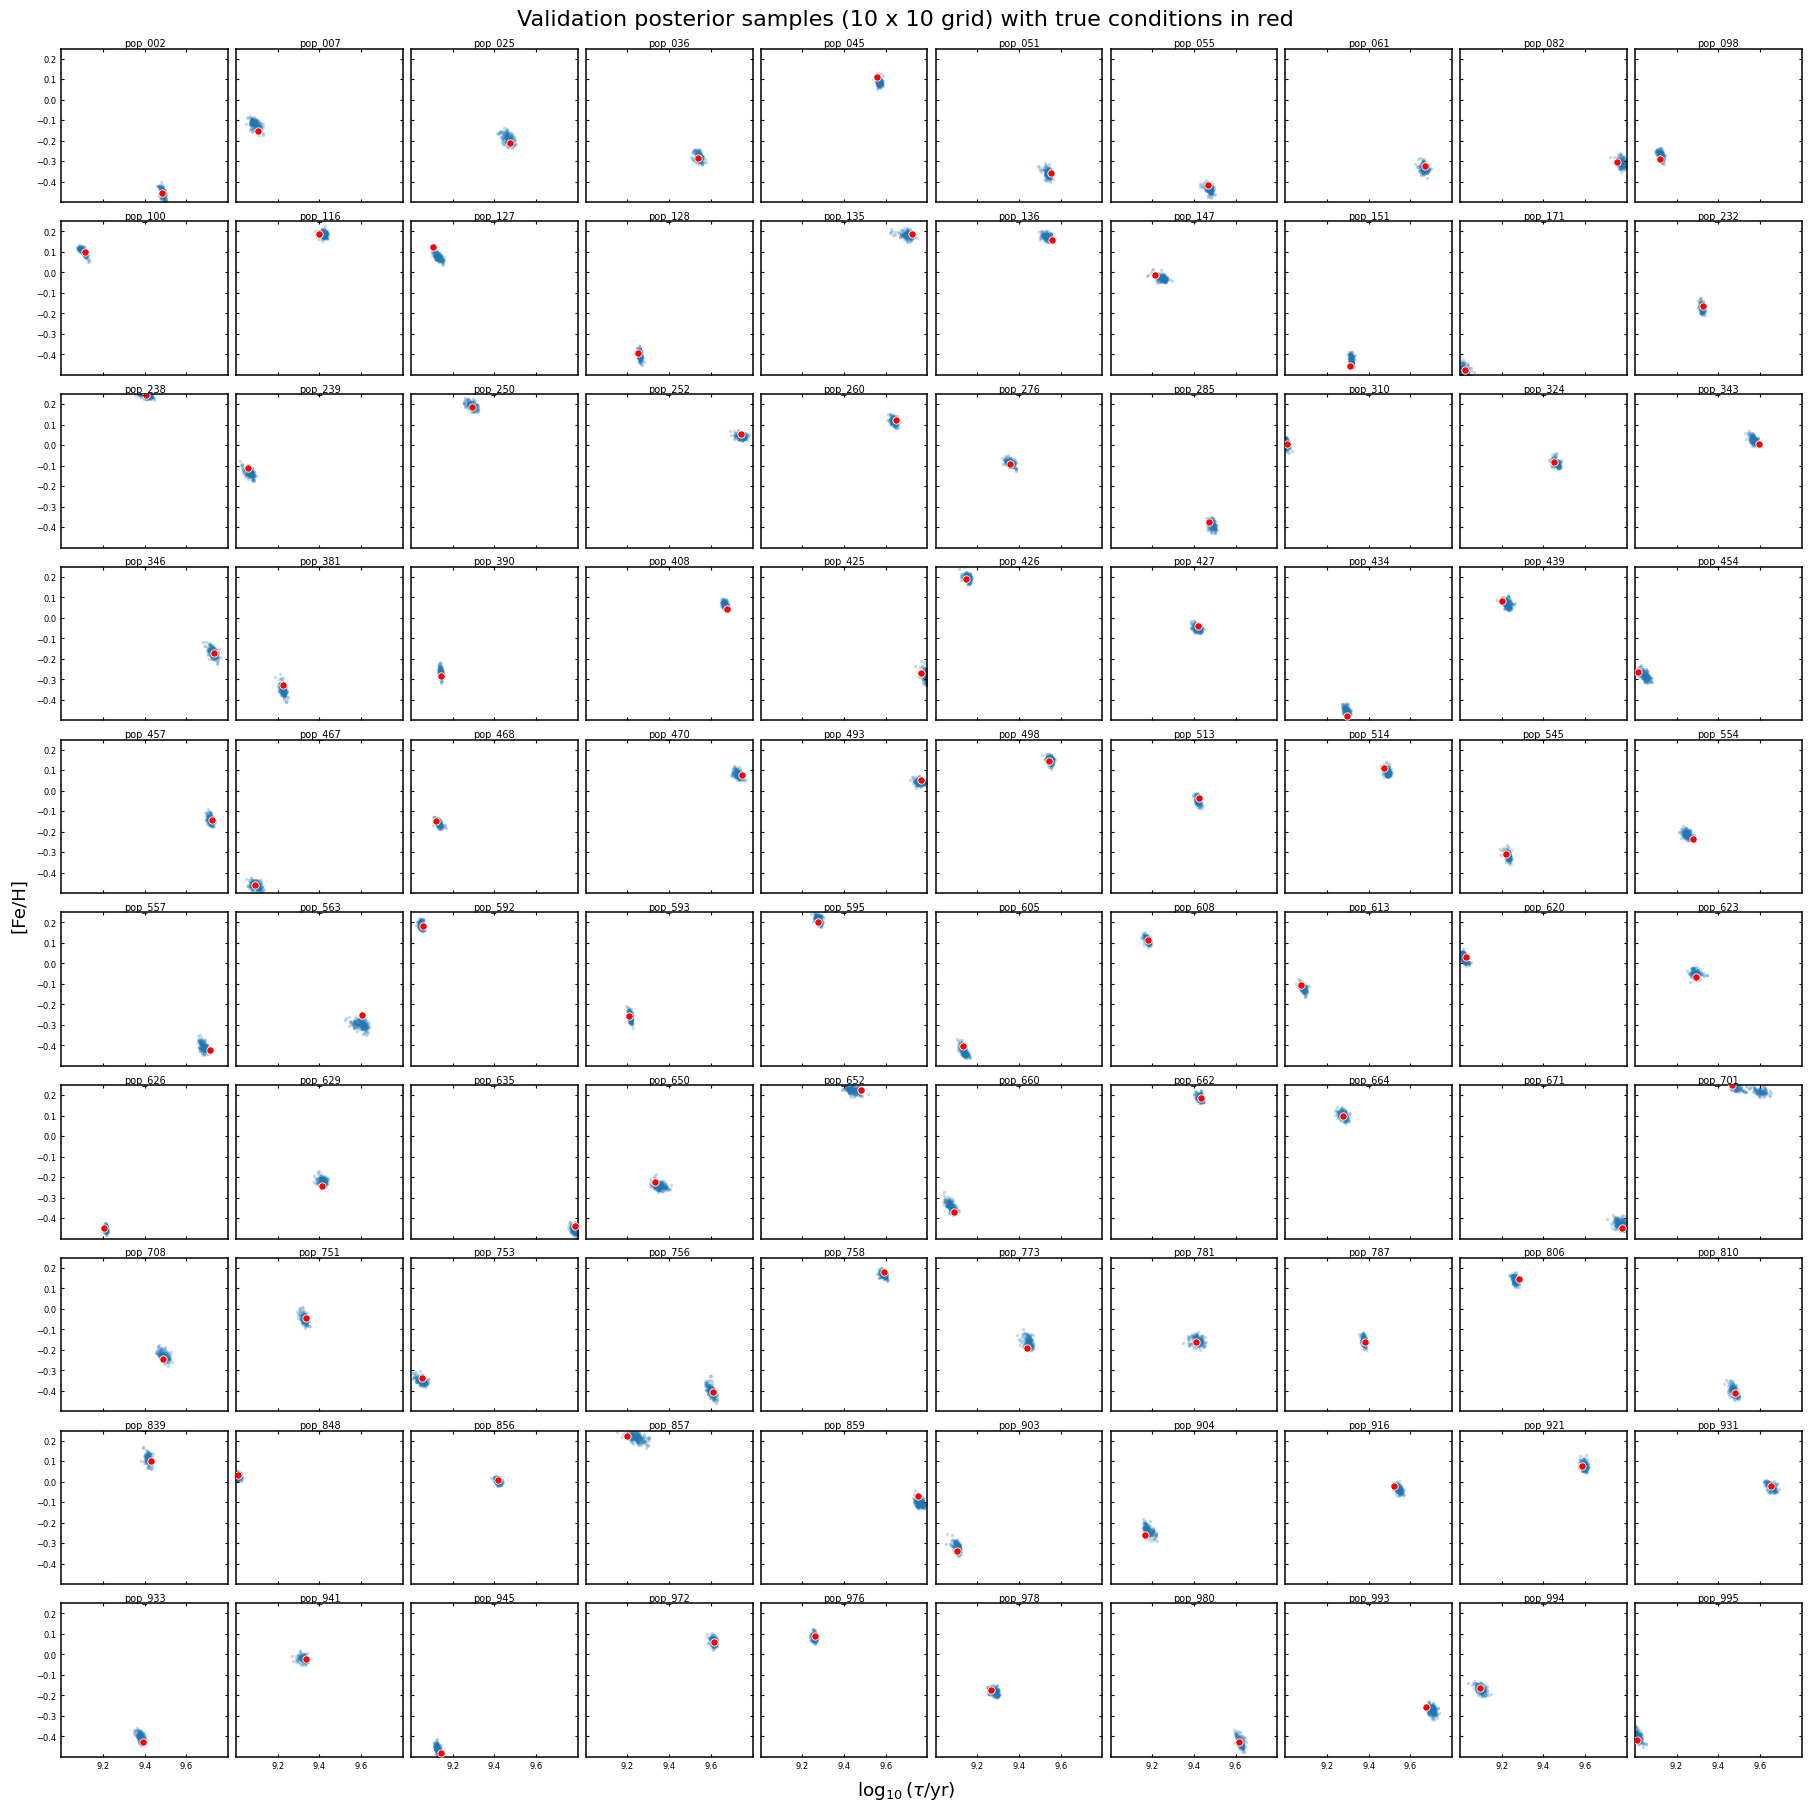

In [11]:

VALIDATION_POSTERIOR_GRID_ROWS = 10
VALIDATION_POSTERIOR_GRID_COLS = 10
VALIDATION_POSTERIOR_MARKER_SIZE = 6
VALIDATION_TRUE_MARKER_SIZE = 28

validation_posterior_samples_grid = np.asarray(
    validation_mcmc_results["posterior_samples_thinned"],
    dtype=np.float32,
)
validation_true_conditions_grid = np.asarray(
    validation_mcmc_results["true_conditions"],
    dtype=np.float32,
)
validation_population_labels_grid = np.asarray(
    validation_mcmc_results["population_labels"],
)

n_validation_panels = validation_posterior_samples_grid.shape[0]
expected_validation_panels = (
    VALIDATION_POSTERIOR_GRID_ROWS * VALIDATION_POSTERIOR_GRID_COLS
)
if n_validation_panels > expected_validation_panels:
    raise ValueError(
        "The 10 x 10 posterior grid supports at most "
        f"{expected_validation_panels} validation populations, "
        f"but received {n_validation_panels}."
    )

fig, axes = plt.subplots(
    VALIDATION_POSTERIOR_GRID_ROWS,
    VALIDATION_POSTERIOR_GRID_COLS,
    figsize=(18.0, 18.0),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = np.asarray(axes)

for panel_index, ax in enumerate(axes.flat):
    row_index = panel_index // VALIDATION_POSTERIOR_GRID_COLS
    col_index = panel_index % VALIDATION_POSTERIOR_GRID_COLS

    if panel_index >= n_validation_panels:
        ax.axis("off")
        continue

    posterior_samples = validation_posterior_samples_grid[panel_index]
    true_condition = validation_true_conditions_grid[panel_index]

    ax.scatter(
        posterior_samples[:, LOG_TAU_COLUMN],
        posterior_samples[:, FEH_COLUMN],
        s=VALIDATION_POSTERIOR_MARKER_SIZE,
        alpha=0.25,
        color="tab:blue",
        linewidths=0,
    )
    ax.scatter(
        [true_condition[LOG_TAU_COLUMN]],
        [true_condition[FEH_COLUMN]],
        s=VALIDATION_TRUE_MARKER_SIZE,
        color="red",
        edgecolors="white",
        linewidths=0.6,
        zorder=3,
    )
    ax.set_xlim(float(min_logage), float(max_logage))
    ax.set_ylim(float(min_feh), float(max_feh))
    ax.set_title(validation_population_labels_grid[panel_index], fontsize=7, pad=2)
    ax.tick_params(axis="both", labelsize=6, length=2)
    if row_index < VALIDATION_POSTERIOR_GRID_ROWS - 1:
        ax.tick_params(labelbottom=False)
    if col_index > 0:
        ax.tick_params(labelleft=False)
    ax.grid(False)

fig.supxlabel(r"$\log_{10}(\tau / \mathrm{yr})$")
fig.supylabel(r"[Fe/H]")
fig.suptitle(
    "Validation posterior samples (10 x 10 grid) with true conditions in red",
    fontsize=16,
)

plt.show()
